<a href="https://colab.research.google.com/github/WVF-1/The-Full-Monty/blob/main/FULPs_V2D_Synthesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FULPs — Version Two D: Evolutionary Synthesis

**V2D integrates the best mechanisms from V2A, V2B, and V2C into a single architecture.**
V2C is the foundation. Nothing that works in V2C has been changed or removed.

---

## What V2D adds on top of V2C

| Source | Mechanism | Where | Effect |
|--------|-----------|-------|--------|
| **V2B** | Directed per-sender inbox | Skepsi FULP 6 | Prevents echo chamber: each Skepsi's outgoing message excludes what it heard from the target |
| **V2B** | Message damping (`BP_PEER_REVIEW_DAMPING`) | Skepsi FULP 6 | Smooths oscillation when the Symposium is active across multiple passes |
| **V2B** | `local_evidence` snapshot | Skepsi | Preserves each Skepsi's raw evaluate() output before any peer messages arrive |
| **V2B** | Belief divergence heatmap | Encephalon / Cell 16 | Shows how far peer review moved each Skepsi from its local evidence |
| **V2A** | Reputation concentration heatmap | Encephalon / Cell 17 | Shows how many observations each Skepsi has accumulated |
| **V2A** | Dirichlet concentration heatmap | Encephalon / Cell 17 | Shows total role evidence per Skepsi (not just entropy) |

---

## What V2D does NOT change

Every mechanism listed below is preserved verbatim from V2C:

- **MicrocellBank** (Cell 6) — stronger models, conditional novelty/anomaly, continuous contradiction. Do not modify.
- **Thompson Sampling** (Cell 7 `activate()`) — Dirichlet sample, not mean.
- **Complementary PSA recruitment** (Cell 8) — complement-biased shell ordering.
- **All hyperparameters** — MAX_PSA_LEVELS=2, CONT_ACCEPT=0.25, CONF_EMERGENCY=0.40, DIRICHLET_INIT=0.25, etc.
- **V2C role learning** (`update_role_vector`) — rewards sampled dominant role only.
- **FULP 7 resolve_contradictions** — evidence-weighted geometric mean (V2A/V2C style).
- **Confidence and contradiction formulas** — unchanged.
- **Memory consolidation** — unchanged.

---

## V2D exclusion rule (FULP 6 upgrade)

In V2C, Skepsi B's outgoing message to Skepsi A includes everything B heard, including
the message that A sent to B. This creates an echo chamber: A's belief amplifies
itself by traveling through B and returning.

V2B solved this with the **exclusion rule**:

> The message from Skepsi i to Skepsi j does NOT include the message i received from j.

V2D grafts this rule onto V2C's geometric mean combination. The math for combining
messages stays the same (log-linear / geometric mean, reputation-weighted). Only the
routing changes: we exclude the target's own prior message before computing what to send.

This is a conservative, targeted addition. It does not change symposium size,
PSA depth, contradiction behaviour, or confidence calculations.


In [ ]:
# ── Cell 1: Install ─────────────────────────────────────────────────────────
import subprocess, sys
for pkg in ['torch','scipy','scikit-learn','pandas','matplotlib','seaborn']:
    subprocess.run([sys.executable,'-m','pip','install',pkg,'--quiet'],capture_output=True)
print('Packages ready.')


Packages ready.


In [ ]:
# ── Cell 2: Imports and Configuration ───────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import torch
import torch.nn as nn
from scipy.linalg import cholesky
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from collections import Counter

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120
OUT_DIR = '/content' if os.path.exists('/content') else '.'

# ── Grid ──────────────────────────────────────────────────────────────────────
GRID_H, GRID_W  = 9, 9
MAX_PSA_LEVELS  = 2
SUBSPACE_FRAC   = 0.6

# ── Thresholds (unchanged) ───────────────────────────────────────────────────
CONF_ACCEPT    = 0.60
CONT_ACCEPT    = 0.25
CONF_EMERGENCY = 0.40
CONT_EMERGENCY = 0.45
MAX_CONTRADICTION_PASSES  = 3
EARLY_STOP_CONTRADICTION  = 0.10

# ── FULP 1 (unchanged) ───────────────────────────────────────────────────────
VOID_HIDDEN, EA_TARGET_STD, EA_WEIGHT = 16, 0.3, 0.5
VOID_EPOCHS, VOID_BATCH               = 100, 128
DSC_CALIBRATION_PERCENTILE            = 75

# ── FULP 2 memory (unchanged) ────────────────────────────────────────────────
WORKING_EMA, EPISODIC_EMA = 0.6, 0.95

# ── FULP 3 context (unchanged) ───────────────────────────────────────────────
CONTEXT_ALPHA = 0.10

# ── V2A Bayesian parameters (preserved) ──────────────────────────────────────
BETA_ALPHA_INIT = 1.0
BETA_BETA_INIT  = 1.0
DIRICHLET_INIT = 0.25
ROLE_INCREMENT = 1.0
DECISIVE_FACTOR = 0.7

# ── FULP 5 signal thresholds (unchanged) ─────────────────────────────────────
NOVELTY_ROLE_THRESH     = 0.30
ANOMALY_ROLE_THRESH     = 0.30
UNCERTAINTY_ROLE_THRESH = 0.35
CONSENSUS_CONT_THRESH   = 0.20

ALL_ROLES = ['pattern','memory','trend','novelty','uncertainty',
             'causality','prediction','anomaly','consensus']

# ── V2C: Thompson Sampling parameters ─────────────────────────────────────────
#
# TS_ROLE_SEED: RNG seed for Dirichlet sampling.
# Each Skepsi uses its own seed (derived from cell seed) so samples
# are reproducible but independent across the grid.
TS_ROLE_SEED = 42

# COMPLEMENT_BIAS:
#   Weight given to the complementary-role score when ranking candidates
#   for PSA expansion. 0 = pure Manhattan shell (V2A/B behaviour).
#   1 = sort entirely by complement score within each shell.
#   0.35 = 20% complement bias, 80% proximity (distance) bias.
COMPLEMENT_BIAS = 0.20

# ── Baselines (unchanged) ─────────────────────────────────────────────────────
RF_N_ESTIMATORS = 100
GNN_K, GNN_EPOCHS, GNN_HIDDEN, GNN_LR = 5, 100, 32, 1e-3

# ── Experiment ────────────────────────────────────────────────────────────────
GLOBAL_SEED = 42
TEST_SIZE   = 0.25

# ── Plotting ─────────────────────────────────────────────────────────────────
TIER_COLORS  = {'S':'#4c72b0','M':'#55a868','L':'#c44e52','XL':'#8172b2'}
MODEL_COLORS = {'RF':'#4c72b0','GNN':'#55a868','FULP2D':'#c44e52'}
ROLE_COLORS  = {
    'pattern':'#4c72b0','memory':'#55a868','trend':'#c44e52','novelty':'#8172b2',
    'uncertainty':'#ccb974','causality':'#64b5cd','prediction':'#dd8452',
    'anomaly':'#937860','consensus':'#76b900',
}
plt.rcParams.update({
    'font.family':'monospace','axes.titlesize':10,'axes.labelsize':9,
    'xtick.labelsize':8,'ytick.labelsize':8,'legend.fontsize':8,
    'axes.grid':True,'grid.alpha':0.3,
})
STATE_INACTIVE   = 'INACTIVE'
STATE_EVALUATING = 'EVALUATING'
STATE_PEER_REVIEW= 'PEER_REVIEW'

print('Configuration loaded.')
print(f'Grid: {GRID_H}x{GRID_W} = {GRID_H*GRID_W} Skepsis  |  MAX_PSA_LEVELS={MAX_PSA_LEVELS}')
print(f'V2C Thompson Sampling parameters:')
print(f'  TS_ROLE_SEED     = {TS_ROLE_SEED}  (per-Skepsi Dirichlet sampling seed)')
print(f'  COMPLEMENT_BIAS  = {COMPLEMENT_BIAS}  (PSA recruitment bias toward complementary roles)')

# ----- V2D additions --------------------------------------------------------
# V2B exclusion-rule peer review: damping on outgoing directed messages.
# 0.0 = fully new message each round (fastest, risk of oscillation on cycles)
# 0.3 = 70% new + 30% previous — responsive but stable. Conservative choice.
BP_PEER_REVIEW_DAMPING = 0.30

print('V2D additions loaded:')
print(f'  BP_PEER_REVIEW_DAMPING = {BP_PEER_REVIEW_DAMPING}')
print('  Directed inbox (exclusion rule) active in Skepsi and Encephalon.')
# ----- end V2D additions ----------------------------------------------------


Configuration loaded.
Grid: 9x9 = 81 Skepsis  |  MAX_PSA_LEVELS=2
V2C Thompson Sampling parameters:
  TS_ROLE_SEED     = 42  (per-Skepsi Dirichlet sampling seed)
  COMPLEMENT_BIAS  = 0.2  (PSA recruitment bias toward complementary roles)
V2D additions loaded:
  BP_PEER_REVIEW_DAMPING = 0.3
  Directed inbox (exclusion rule) active in Skepsi and Encephalon.


In [ ]:
# ── Cell 3: Synthetic Datasets (unchanged) ───────────────────────────────────
TIER_SIZES = {'S':200,'M':400,'L':800,'XL':1600}

def _gen_S(n,rng):
    f1=rng.normal(0,1,n); f2=rng.normal(0,1,n); f3=rng.normal(0,1,n)
    s=1.5*f1-1.2*f2+0.3*f3+rng.normal(0,0.15,n)
    return pd.DataFrame({'f1':f1,'f2':f2,'f3':f3}),(s>0).astype(int),s

def _gen_M(n,rng):
    X,_,s=_gen_S(n,rng); f4=rng.normal(0,1,n); f5=rng.normal(0,1,n)
    sm=s+0.8*f4**2-0.5*f4*X['f2'].values+rng.normal(0,0.25,n)
    X['f1']+=rng.normal(0,0.05,n); X['f2']+=rng.normal(0,0.05,n)
    X['f4']=f4; X['f5']=f5
    return X,np.where(sm>0.4,1,np.where(sm<-0.4,0,2)),sm

def _gen_L(n,rng):
    f2=rng.normal(0,1,n); f3=rng.normal(0,1,n); f4=rng.normal(0,1,n); f5=rng.normal(0,1,n)
    f1=np.zeros(n); f1[0]=rng.normal(0,1)
    for t in range(1,n): f1[t]=0.6*f1[t-1]+0.4*rng.normal(0,1)
    f6=np.roll(f1,1); f6[0]=0.0
    sl=1.5*f1-1.2*f2+0.3*f3+0.8*f4**2-0.5*f4*f2+0.5*f1*f4+0.4*f6+rng.normal(0,0.40,n)
    return pd.DataFrame({'f1':f1,'f2':f2,'f3':f3,'f4':f4,'f5':f5,'f6':f6}),np.digitize(sl,np.quantile(sl,[.25,.5,.75])),sl

def _gen_XL(n,rng):
    X,_,sl=_gen_L(n,rng)
    xc=rng.uniform(0,10,n); yc=rng.uniform(0,10,n)
    d=np.stack([np.hypot(xc-c[0],yc-c[1]) for c in [[2,2],[8,2],[5,8]]],axis=1)
    sxl=sl+(d.argmin(axis=1)-1.0)*1.2+rng.normal(0,0.30,n)
    y=np.digitize(sxl,np.quantile(sxl,[.2,.4,.6,.8]))
    contra=np.hypot(xc-5,yc-5)<1.5
    if contra.sum()>0: y[contra]=rng.integers(0,5,contra.sum())
    X['x_coord']=xc; X['y_coord']=yc
    X['f7_irr']=rng.normal(0,1,n); X['f8_irr']=rng.uniform(-1,1,n)
    X['contradiction_zone']=contra.astype(int)
    return X,y,sxl

_GEN={'S':_gen_S,'M':_gen_M,'L':_gen_L,'XL':_gen_XL}

def generate_dataset(tier,n=None,seed=42):
    rng=np.random.default_rng(seed); n=n or TIER_SIZES[tier]
    X,y,_=_GEN[tier](n,rng)
    return X.reset_index(drop=True),np.asarray(y),int(np.unique(y).size)

for t in ['S','M','L','XL']:
    X,y,k=generate_dataset(t)
    print(f'{t}: rows={len(X)} features={X.shape[1]} classes={k}')


S: rows=200 features=3 classes=2
M: rows=400 features=5 classes=3
L: rows=800 features=6 classes=4
XL: rows=1600 features=11 classes=5


In [ ]:
# ── Cell 4: FULP 1 — VoidStabilizer (unchanged) ─────────────────────────────

class InnerDepthField:
    def __init__(self,dim): self.dim=dim
    def _corr(self,rho):
        idx=np.arange(self.dim)
        return rho**np.abs(idx[:,None]-idx[None,:])+np.eye(self.dim)*1e-6
    def sample(self,n,rng):
        X=np.zeros((n,self.dim))
        for i in range(n):
            mu=rng.normal(0,0.02); sig=rng.uniform(0.05,0.30); rho=rng.uniform(-0.2,0.2)
            try:
                L=cholesky(self._corr(rho),lower=True); X[i]=mu+sig*(L@rng.normal(0,1,self.dim))
            except: X[i]=rng.normal(mu,sig,self.dim)
        return X.astype(np.float32)

class VoidStabilizer(nn.Module):
    def __init__(self,dim,hidden=VOID_HIDDEN,ea_target_std=EA_TARGET_STD,ea_weight=EA_WEIGHT):
        super().__init__()
        self.ea_target_std=ea_target_std; self.ea_weight=ea_weight
        self.encoder=nn.Sequential(nn.Linear(dim,hidden),nn.Tanh()); self.decoder=nn.Linear(hidden,dim)
    def forward(self,x): z=self.encoder(x); return self.decoder(z),z
    def dsc(self,x): x_hat,_=self.forward(x); return torch.mean((x-x_hat)**2,dim=1)
    def training_loss(self,x):
        x_hat,z=self.forward(x)
        r=nn.functional.mse_loss(x_hat,x); e=(z.std()-self.ea_target_std)**2
        return r+self.ea_weight*e,r.item(),e.item()

def train_void_stabilizer(dim,seed=GLOBAL_SEED,n_epochs=VOID_EPOCHS,batch_size=VOID_BATCH):
    rng=np.random.default_rng(seed); idf=InnerDepthField(dim); model=VoidStabilizer(dim)
    opt=torch.optim.Adam(model.parameters(),lr=1e-3)
    for _ in range(n_epochs):
        x=torch.FloatTensor(idf.sample(batch_size,rng))
        loss,_,_=model.training_loss(x); opt.zero_grad(); loss.backward(); opt.step()
    model.eval(); return model,idf

def calibrate_dsc_threshold(void_model,idf,rng,X_scaled,percentile=DSC_CALIBRATION_PERCENTILE):
    with torch.no_grad():
        err=void_model.dsc(torch.FloatTensor(X_scaled.astype(np.float32))).numpy()
    return float(np.percentile(err,percentile))

print('FULP 1 — VoidStabilizer defined (unchanged).')


FULP 1 — VoidStabilizer defined (unchanged).


In [ ]:
# ── Cell 5: Bayesian Utilities and Geometric Mean (preserved from V2A) ────────

class BetaEstimator:
    def __init__(self,alpha=BETA_ALPHA_INIT,beta=BETA_BETA_INIT):
        self.alpha=float(alpha); self.beta=float(beta)
    @property
    def mean(self): return self.alpha/(self.alpha+self.beta)
    @property
    def variance(self):
        a,b=self.alpha,self.beta; return a*b/((a+b)**2*(a+b+1))
    @property
    def concentration(self): return self.alpha+self.beta-BETA_ALPHA_INIT-BETA_BETA_INIT
    def update(self,success):
        if success: self.alpha+=1.0
        else:       self.beta +=1.0
    def __repr__(self):
        return f'Beta(a={self.alpha:.1f},b={self.beta:.1f}) mean={self.mean:.3f}'


class DirichletEstimator:
    """
    Dirichlet posterior over role space.

    V2A/V2B use .means (expected value) as role weights — deterministic exploitation.
    V2C uses .sample() (Thompson Sampling) — stochastic exploration + exploitation.
    The alpha parameters are updated identically across all three versions.
    """
    def __init__(self,categories=ALL_ROLES,alpha_init=DIRICHLET_INIT):
        self.alpha={c:float(alpha_init) for c in categories}

    @property
    def means(self):
        """Deterministic posterior mean. Used by V2A and V2B."""
        total=sum(self.alpha.values()); return {c:self.alpha[c]/total for c in self.alpha}

    def sample(self,rng):
        """
        Thompson Sampling: draw one sample from Dirichlet(alpha).
        Returns a dict of role->weight for this inference only.
        The sampled weights are stochastic but distributed according to
        current posterior uncertainty. High-alpha roles dominate most draws;
        low-alpha roles occasionally win and get to prove themselves.
        """
        alpha_vec=np.array([self.alpha[r] for r in ALL_ROLES])
        sampled=rng.dirichlet(alpha_vec)
        return {r:float(sampled[i]) for i,r in enumerate(ALL_ROLES)}

    @property
    def concentration(self): return sum(self.alpha.values())-len(self.alpha)*DIRICHLET_INIT

    @property
    def dominant(self): return max(self.alpha,key=self.alpha.get)

    @property
    def entropy(self):
        p=np.array(list(self.means.values())); p=np.clip(p,1e-10,1.0)
        return float(-np.sum(p*np.log(p))/np.log(len(p)))

    def update(self,role,increment=1.0):
        if role in self.alpha: self.alpha[role]+=float(increment)

    def __repr__(self):
        return f'Dirichlet(dominant={self.dominant}, conc={self.concentration:.1f}, H={self.entropy:.3f})'


def log_combine_probs(probs_list,weights):
    """Reputation-weighted geometric mean. Preserved from V2A."""
    weights=np.array(weights,dtype=float); weights=np.clip(weights,1e-9,None)
    log_c=np.zeros(len(probs_list[0]))
    for p,w in zip(probs_list,weights):
        log_c+=w*np.log(np.clip(np.asarray(p),1e-10,1.0))
    log_c-=log_c.max(); c=np.exp(log_c); return c/(c.sum()+1e-10)


print('Bayesian utilities defined.')
print('  BetaEstimator:     Beta posterior for reputation and cooperation')
print('  DirichletEstimator: .means = deterministic (V2A/B)')
print('                      .sample(rng) = Thompson Sampling (V2C)')
print('  log_combine_probs: geometric mean for FULP 6/7')


Bayesian utilities defined.
  BetaEstimator:     Beta posterior for reputation and cooperation
  DirichletEstimator: .means = deterministic (V2A/B)
                      .sample(rng) = Thompson Sampling (V2C)
  log_combine_probs: geometric mean for FULP 6/7


In [ ]:
# ── Cell 6: MicrocellBank (Version 2D) ───────────────────────────────────────

def _full_proba(clf, x_row, n_classes):
    p = clf.predict_proba(x_row.reshape(1,-1))[0]
    out = np.zeros(n_classes)
    for c, pc in zip(clf.classes_, p):
        out[int(c)] = pc
    s = out.sum()
    return out/s if s > 0 else np.full(n_classes,1.0/n_classes)


class MicrocellBank:

    def __init__(self, feature_idx, causal_idx,
                 void_model, dsc_threshold, seed):

        self.feature_idx = feature_idx
        self.causal_idx = causal_idx

        self.void_model = void_model
        self.dsc_threshold = dsc_threshold
        self.seed = seed

        self.n_classes = None
        self.activated = False

        self.working_memory = None
        self.episodic_memory = None

        self._last_novelty = 0.0
        self._last_anomaly = 0.0


    def fit(self, X_train, y_train, n_classes):

        self.n_classes = n_classes

        Xs = X_train[:, self.feature_idx]
        Xc = X_train[:, self.causal_idx]

        # Stronger models
        self.pattern_clf = DecisionTreeClassifier(
            max_depth=6,
            random_state=self.seed
        ).fit(Xs, y_train)

        self.prediction_clf = RandomForestClassifier(
            n_estimators=30,
            max_depth=8,
            random_state=self.seed
        ).fit(Xs, y_train)

        self.trend_clf = LogisticRegression(
            max_iter=1000,
            random_state=self.seed
        ).fit(Xs, y_train)

        self.causality_clf = DecisionTreeClassifier(
            max_depth=5,
            random_state=self.seed
        ).fit(Xc, y_train)

        self._anomaly_mean = Xs.mean(axis=0)

        return self


    def reset_working_memory(self):
        self.working_memory = None


    def consolidate_memory(self, final_probs):

        if self.episodic_memory is None:
            self.episodic_memory = final_probs.copy()

        else:
            # Faster adaptation than before
            self.episodic_memory = (
                0.85*self.episodic_memory
                + 0.15*final_probs
            )


    def evaluate(self, x_full, role_weights=None):

        self.activated = True

        n = self.n_classes

        xs = x_full[self.feature_idx]
        xc = x_full[self.causal_idx]

        pv  = _full_proba(self.pattern_clf, xs, n)
        prv = _full_proba(self.prediction_clf, xs, n)
        tv  = _full_proba(self.trend_clf, xs, n)
        cv  = _full_proba(self.causality_clf, xc, n)

        # ---- novelty ----
        with torch.no_grad():
            dsc = float(
                self.void_model.dsc(
                    torch.FloatTensor(x_full).unsqueeze(0)
                )
            )

        nov = float(
            np.clip(
                dsc/(self.dsc_threshold+1e-8)-1.0,
                0,
                1
            )
        )

        # ---- anomaly ----
        az = float(np.mean(np.abs(xs-self._anomaly_mean)))

        anom = float(
            np.clip(
                (az-1.0)/2.0,
                0,
                1
            )
        )

        self._last_novelty = nov
        self._last_anomaly = anom

        # ---- raw average ----
        raw_avg = np.mean(
            [pv, prv, tv, cv],
            axis=0
        )

        # ---- working memory ----
        if self.working_memory is None:
            self.working_memory = raw_avg.copy()

        else:
            self.working_memory = (
                0.4*self.working_memory
                + 0.6*raw_avg
            )

        # ---- episodic memory ----
        if self.episodic_memory is not None:

            mv = (
                0.7*self.working_memory
                + 0.3*self.episodic_memory
            )

        else:
            mv = self.working_memory.copy()

        # =====================================================
        # Consensus
        # =====================================================

        vectors = [pv, prv, tv, cv, mv]

        # only activate novelty when significant
        if nov > 0.20:

            novelty_vec = np.full(n,1.0/n)

            vectors.append(novelty_vec)

        # only activate anomaly when significant
        if anom > 0.20:

            anomaly_vec = np.full(n,1.0/n)

            vectors.append(anomaly_vec)

        all_v = np.stack(vectors)

        cons = np.mean(all_v, axis=0)

        # =====================================================
        # Uncertainty
        # =====================================================

        p = np.clip(cons,1e-9,1.0)

        H = -np.sum(
            p*np.log(p)
        ) / np.log(n)

        cc = int(np.argmax(cons))

        # =====================================================
        # Contradiction
        # probability disagreement
        # =====================================================

        disagreement = np.mean([
            np.mean(np.abs(pv-prv)),
            np.mean(np.abs(pv-tv)),
            np.mean(np.abs(pv-cv)),
            np.mean(np.abs(pv-mv))
        ])

        contradiction = float(
            np.clip(
                disagreement
                + 0.30*anom
                + 0.30*nov,
                0,
                1
            )
        )

        # =====================================================
        # Confidence
        # =====================================================

        confidence = float(
            np.clip(
                np.max(cons)
                * (1-0.4*H)
                * (1-0.3*nov)
                * (1-0.2*anom),
                0,
                1
            )
        )

        return {
            'probs': cons,
            'prediction': cc,
            'confidence': confidence,
            'contradiction': contradiction,
            'novelty': nov,
            'anomaly': anom,
            'uncertainty': H,
            'memory_vec': mv,
            'n_microcells_run': len(vectors),

            'microcell_predictions':{
                'pattern': int(np.argmax(pv)),
                'prediction': int(np.argmax(prv)),
                'trend': int(np.argmax(tv)),
                'causality': int(np.argmax(cv)),
                'memory': int(np.argmax(mv))
            }
        }


print("MicrocellBank V2D defined.")

MicrocellBank V2D defined.


In [ ]:
# ── Cell 7: Skepsi V2D ───────────────────────────────────────────────────────
#
# V2C base preserved verbatim. Three V2D additions are marked.
#
# ----- V2D additions (from V2B) -----
#
# 1. self.local_evidence
#    The raw probs from evaluate() before any peer messages arrive.
#    Stored in activate() alongside initial_result.
#    Used by update_belief() and belief_divergence_heatmap().
#
# 2. self.inbox  (dict: sender_pos -> message)
#    Directed per-sender inbox replacing the flat self.mailbox list.
#    Preserves sender identity so we can apply the exclusion rule.
#
# 3. self.outbox  (dict: target_pos -> np.ndarray)
#    Stores the most recent outgoing message to each neighbour.
#    Used for damping: new_msg = (1-d)*computed + d*previous.
#
# compute_message_to(target_pos):
#    EXCLUSION RULE — builds an outgoing message that excludes whatever
#    this Skepsi received FROM target. Prevents echo-chamber amplification.
#    Combines remaining evidence via reputation-weighted geometric mean.
#    Applies BP_PEER_REVIEW_DAMPING against the previous outbox entry.
#
# receive_directed_message(sender_pos, msg):
#    Stores message keyed by sender position (replaces receive_message).
#
# apply_directed_messages():
#    Recomputes belief from ALL inbox messages using geometric mean.
#    Replaces apply_messages().
#
# The original flat mailbox methods (compose_message, receive_message,
# apply_messages) are retained as fallbacks for compatibility.
# ----- end V2D additions -----

class Skepsi:
    """V2D Skepsi: V2C Thompson Sampling + V2B directed inbox (exclusion rule)."""

    def __init__(self,row,col,feature_idx,causal_idx,void_model,dsc_threshold,seed):
        self.row=row; self.col=col
        self.bank=MicrocellBank(feature_idx,causal_idx,void_model,dsc_threshold,seed)
        self.state=STATE_INACTIVE; self.result=None; self.initial_result=None

        # ── V2A Bayesian state (preserved from V2C) ─────────────────────
        self.rep_beta       = BetaEstimator()
        self.role_dirichlet = DirichletEstimator()
        self.coop_beta      = BetaEstimator()
        self.context={'samples_seen':0,'avg_confidence':0.0,
                      'avg_contradiction':0.0,'avg_novelty':0.0}

        # ── V2C: Thompson Sampling (preserved) ───────────────────────────
        self.ts_rng = np.random.default_rng(seed + TS_ROLE_SEED)
        self.sampled_role_history = []
        self.sampled_weights_last = None

        # ----- V2D additions (from V2B) -------------------------------------
        self.local_evidence = None   # raw evaluate() probs, never overwritten
        self.inbox          = {}     # {(r,c): {'probs':..., 'reputation':...}}
        self.outbox         = {}     # {(r,c): np.ndarray} previous sent messages
        # ----- end V2D additions -------------------------------------------

    def fit(self,X_train,y_train,n_classes):
        self.bank.fit(X_train,y_train,n_classes); return self

    # ── Properties (identical to V2C) ────────────────────────────────────
    @property
    def reputation(self): return self.rep_beta.mean
    @property
    def cooperation(self): return self.coop_beta.mean
    @property
    def role_vector(self): return self.role_dirichlet.means
    @property
    def dominant_role(self): return self.role_dirichlet.dominant

    @property
    def exploration_rate(self):
        if not self.sampled_role_history: return 0.0
        det_dom = self.dominant_role
        return float(sum(r != det_dom for r in self.sampled_role_history) /
                     len(self.sampled_role_history))

    @property
    def sampled_dominant_counts(self):
        return Counter(self.sampled_role_history)

    @property
    def stubbornness(self):
        """Emergent from reputation x confidence (unchanged from V2C)."""
        if self.result is not None:
            return float(np.clip(self.rep_beta.mean*self.result['confidence'],0.05,0.95))
        return float(np.clip(self.rep_beta.mean,0.05,0.95))

    # ── Per-sample lifecycle ──────────────────────────────────────────────
    def reset(self):
        self.state=STATE_INACTIVE; self.result=None; self.initial_result=None
        self.bank.reset_working_memory()
        # ----- V2D additions -----
        self.local_evidence = None
        self.inbox          = {}
        self.outbox         = {}
        # ----- end V2D additions -----

    def activate(self,x_scaled,state=STATE_EVALUATING):
        """
        V2C Thompson Sampling preserved verbatim.
        V2D addition: save local_evidence immediately after evaluate().
        """
        self.state=state
        sampled_weights = self.role_dirichlet.sample(self.ts_rng)
        self.sampled_weights_last = sampled_weights
        sampled_dom = max(sampled_weights, key=sampled_weights.get)
        self.sampled_role_history.append(sampled_dom)
        raw = self.bank.evaluate(x_scaled, role_weights=sampled_weights)
        self.initial_result = {k:raw[k].copy() if isinstance(raw[k],np.ndarray) else raw[k]
                               for k in raw}
        self.result = raw
        # ----- V2D addition: local_evidence snapshot -----
        self.local_evidence = raw['probs'].copy()
        # ----- end V2D addition -----
        return self.result

    # ── V2C learning and memory (preserved verbatim) ─────────────────────
    def consolidate_memory(self):
        if self.result is not None: self.bank.consolidate_memory(self.result['probs'])

    def update_context(self,result):
        n=self.context['samples_seen']
        if n==0:
            self.context.update(avg_confidence=result['confidence'],
                                avg_contradiction=result['contradiction'],
                                avg_novelty=result.get('novelty',0.0))
        else:
            a=CONTEXT_ALPHA
            self.context['avg_confidence']   =(1-a)*self.context['avg_confidence']   +a*result['confidence']
            self.context['avg_contradiction']=(1-a)*self.context['avg_contradiction']+a*result['contradiction']
            self.context['avg_novelty']      =(1-a)*self.context['avg_novelty']      +a*result.get('novelty',0.0)
        self.context['samples_seen']+=1

    def update_reputation(self,was_correct):
        self.rep_beta.update(was_correct)

    def update_role_vector(self, result, was_correct, agreed):
        """V2C role learning — preserved verbatim. Rewards sampled dominant role only."""
        if not was_correct: return
        sampled_role = self.sampled_role_history[-1]
        self.role_dirichlet.update(sampled_role, ROLE_INCREMENT)
        novelty = result.get('novelty',0.0)
        anomaly = result.get('anomaly',0.0)
        uncertainty = result.get('uncertainty',1.0)
        contradiction = result.get('contradiction',1.0)
        if novelty > NOVELTY_ROLE_THRESH:         self.role_dirichlet.update('novelty',0.5)
        if anomaly > ANOMALY_ROLE_THRESH:         self.role_dirichlet.update('anomaly',0.5)
        if uncertainty < UNCERTAINTY_ROLE_THRESH: self.role_dirichlet.update('uncertainty',0.5)
        if contradiction < CONSENSUS_CONT_THRESH and agreed:
            self.role_dirichlet.update('consensus',0.5)

    def update_cooperation(self,was_in_peer_review,prediction_correct):
        if was_in_peer_review: self.coop_beta.update(prediction_correct)

    # ── V2C flat mailbox (preserved for compatibility) ────────────────────
    def compose_message(self):
        if self.result is None: return None
        return {'probs':self.result['probs'].copy(),'confidence':self.result['confidence'],
                'contradiction':self.result['contradiction'],'memory_vec':self.result['memory_vec'].copy(),
                'reputation':self.reputation,'cooperation':self.cooperation}

    def receive_message(self,msg):
        if msg is not None:
            if not hasattr(self,'mailbox'): self.mailbox=[]
            self.mailbox.append(msg)

    def apply_messages(self,x_scaled):
        """V2C flat mailbox fusion — retained for fallback compatibility."""
        mb = getattr(self,'mailbox',[])
        if not mb or self.result is None: return self.result
        probs_list=[self.result['probs']]
        weights   =[self.reputation*self.result['confidence']]
        for msg in mb:
            probs_list.append(msg['probs'])
            weights.append(msg.get('reputation',0.5)*msg.get('confidence',0.5))
        combined=log_combine_probs(probs_list,weights)
        self.result['probs']=combined; self.result['prediction']=int(np.argmax(combined))
        self.result['confidence']=float(np.max(combined))
        return self.result

    # ----- V2D additions: directed inbox with exclusion rule (from V2B) -----

    def compute_message_to(self, target_pos):
        """
        V2D (from V2B): Exclusion-rule message computation.

        Builds an outgoing message to target_pos that:
          (a) starts from this Skepsi's local_evidence (never overwritten),
          (b) adds all inbox messages EXCEPT the one from target_pos,
          (c) combines via reputation-weighted geometric mean,
          (d) applies BP_PEER_REVIEW_DAMPING against previous outbox entry.

        The exclusion of target's message prevents echo-chamber amplification.
        A's opinion does not return to A amplified through B.
        """
        if self.local_evidence is None:
            return None

        # Own evidence weighted by reputation
        log_msg = self.rep_beta.mean * np.log(np.clip(self.local_evidence, 1e-10, 1.0))

        # Add all inbox EXCEPT from target
        for sender_pos, msg_info in self.inbox.items():
            if sender_pos != target_pos:
                w = msg_info.get('reputation', 0.5)
                log_msg += w * np.log(np.clip(msg_info['probs'], 1e-10, 1.0))

        # Normalise
        log_msg -= log_msg.max()
        new_msg = np.exp(log_msg); new_msg /= new_msg.sum() + 1e-10

        # Damping: blend with previous outgoing message if available
        if target_pos in self.outbox:
            new_msg = ((1 - BP_PEER_REVIEW_DAMPING) * new_msg
                       + BP_PEER_REVIEW_DAMPING * self.outbox[target_pos])
            new_msg /= new_msg.sum() + 1e-10

        return new_msg

    def receive_directed_message(self, sender_pos, msg):
        """V2D: store message keyed by sender position."""
        if msg is not None:
            self.inbox[sender_pos] = {
                'probs':      msg['probs'].copy() if isinstance(msg['probs'], np.ndarray) else msg['probs'],
                'reputation': msg.get('reputation', 0.5),
            }

    def apply_directed_messages(self):
        """
        V2D: Recompute belief from local_evidence + all inbox messages.
        Combination is the same geometric mean as V2C (log-linear).
        The difference from V2C is that each sender's contribution is
        excluded from that sender's outgoing message (exclusion rule),
        which happened at compute_message_to() time.
        """
        if self.local_evidence is None or self.result is None:
            return self.result

        log_b = self.rep_beta.mean * np.log(np.clip(self.local_evidence, 1e-10, 1.0))
        for msg_info in self.inbox.values():
            w = msg_info.get('reputation', 0.5)
            log_b += w * np.log(np.clip(msg_info['probs'], 1e-10, 1.0))

        log_b -= log_b.max()
        belief = np.exp(log_b); belief /= belief.sum() + 1e-10

        self.result['probs']      = belief
        self.result['prediction'] = int(np.argmax(belief))
        self.result['confidence'] = float(np.max(belief))
        return self.result

    # ----- end V2D additions -----

    @property
    def is_accepted(self):
        if self.result is None: return False
        return self.result['confidence']>=CONF_ACCEPT and self.result['contradiction']<=CONT_ACCEPT

    def __repr__(self):
        er=self.exploration_rate
        return (f'Skepsi({self.row},{self.col}) rep={self.reputation:.2f} '
                f'coop={self.cooperation:.2f} dominant={self.dominant_role} '
                f'explore={er:.2f} state={self.state}')

print('Skepsi V2D defined.')
print('  V2C preserved: Thompson Sampling, role learning, memory, context, reputation')
print('  V2D added (from V2B): local_evidence, directed inbox, exclusion-rule message computation')
print(f'  BP_PEER_REVIEW_DAMPING = {BP_PEER_REVIEW_DAMPING}')


Skepsi V2D defined.
  V2C preserved: Thompson Sampling, role learning, memory, context, reputation
  V2D added (from V2B): local_evidence, directed inbox, exclusion-rule message computation
  BP_PEER_REVIEW_DAMPING = 0.3


In [ ]:
# ── Cell 8: Encephalon V2D ───────────────────────────────────────────────────
#
# V2C base preserved: complementary PSA recruitment, resolve_contradictions,
# predict_single structure, update_skepsi_stats. All thresholds unchanged.
#
# ----- V2D additions (from V2B) -----
# directed_peer_review_pass():
#   Replaces V2C's peer_review_pass() in predict_single().
#   Implements one synchronous round of directed message passing:
#     Step 1: All outgoing messages computed simultaneously using
#             compute_message_to() — exclusion rule applied at each sender.
#     Step 2: All directed inboxes updated atomically.
#     Step 3: All beliefs recomputed via apply_directed_messages().
#   Synchronous schedule prevents cascading updates within a single round.
#
# New heatmaps (from V2A and V2B):
#   belief_divergence_heatmap()     — V2B: L1(belief, local_evidence)
#   reputation_concentration_heatmap() — V2A: rep_beta observation count
#   dirichlet_concentration_heatmap()  — V2A: total role evidence per Skepsi
#   role_entropy_heatmap()             — V2A: Dirichlet entropy
# ----- end V2D additions -----

def _vn_shell(row,col,level,H,W):
    cells=[]
    if level==0: return [(row,col)]
    for dr in range(-level,level+1):
        dc_abs=level-abs(dr)
        for dc in ([dc_abs,-dc_abs] if dc_abs!=0 else [0]):
            r,c=row+dr,col+dc
            if 0<=r<H and 0<=c<W: cells.append((r,c))
    return cells

def _vn_up_to(row,col,level,H,W):
    cells=set()
    for lv in range(level+1): cells.update(_vn_shell(row,col,lv,H,W))
    return sorted(cells)


class Encephalon:
    """V2D Encephalon: V2C complementary PSA + V2B directed peer review."""

    def __init__(self,grid_h=GRID_H,grid_w=GRID_W,subspace_frac=SUBSPACE_FRAC,
                 void_seed=GLOBAL_SEED,seed=GLOBAL_SEED):
        self.grid_h=grid_h; self.grid_w=grid_w
        self.center=(grid_h//2,grid_w//2)
        self.subspace_frac=subspace_frac; self.seed=seed; self.void_seed=void_seed
        self.rng=np.random.default_rng(seed); self.scaler=StandardScaler()
        self.void_model=None; self.idf=None; self.dsc_threshold=None
        self.n_classes=None; self.n_features=None; self.void_dim=None
        self.grid=None; self._plato=None

    @property
    def plato(self): return self._plato

    def _build_grid(self):
        n=self.n_features; n_sub=max(1,int(n*self.subspace_frac))
        causal=[0,1] if n>=2 else [0]; grid=[]
        for r in range(self.grid_h):
            row=[]
            for c in range(self.grid_w):
                sub=sorted(set(self.rng.choice(n,n_sub,replace=False).tolist())|set(causal))
                seed=int(self.rng.integers(0,1_000_000))
                sk=Skepsi(r,c,sub,causal,self.void_model,self.dsc_threshold,seed)
                sk.mailbox=[]
                row.append(sk)
            grid.append(row)
        cr,cc=self.center; self._plato=grid[cr][cc]
        return grid

    def fit(self,X_df,y,n_classes,verbose=True):
        X_raw=X_df.values.astype(np.float32)
        self.n_features=X_raw.shape[1]; self.n_classes=n_classes; self.void_dim=self.n_features
        if verbose: print('  [Enc] Training VoidStabilizer (FULP 1)...')
        self.void_model,self.idf=train_void_stabilizer(self.void_dim,seed=self.void_seed)
        rng_cal=np.random.default_rng(self.void_seed)
        X_scaled=self.scaler.fit_transform(X_raw).astype(np.float32)
        self.dsc_threshold=calibrate_dsc_threshold(self.void_model,self.idf,rng_cal,X_scaled)
        if verbose: print(f'  [Enc] DSC threshold (p{DSC_CALIBRATION_PERCENTILE}): {self.dsc_threshold:.4f}')
        self.grid=self._build_grid()
        if verbose: print(f'  [Enc] Fitting {self.grid_h*self.grid_w} Skepsis...')
        for r in range(self.grid_h):
            for c in range(self.grid_w): self.grid[r][c].fit(X_scaled,y,n_classes)
        if verbose: print(f'  [Enc] Plato: {self._plato}')
        if verbose: print('  [Enc] Encephalon V2D ready.')
        return self

    def _cell(self,r,c): return self.grid[r][c]

    # ── V2C: Complementary PSA recruitment (preserved verbatim) ──────────
    def _complement_score(self,r,c,active_set):
        sk=self._cell(r,c)
        candidate_dom=sk.dominant_role
        count=sum(1 for (ar,ac) in active_set
                  if self._cell(ar,ac).dominant_role==candidate_dom)
        return 1.0/(1.0+count)

    def _sort_candidates_by_complement(self,new_cells,active_set):
        if not active_set: return new_cells
        scored=[]
        for (r,c) in new_cells:
            cs=self._complement_score(r,c,active_set)
            rs=COMPLEMENT_BIAS*cs + (1-COMPLEMENT_BIAS)*1.0
            scored.append((rs,r,c))
        scored.sort(key=lambda x:-x[0])
        return [(r,c) for _,r,c in scored]

    # ----- V2D addition: directed peer review with exclusion rule -----
    def directed_peer_review_pass(self, active_set):
        """
        V2D (from V2B): synchronous directed belief propagation.

        Step 1: Compute all outgoing messages simultaneously.
                Each sender calls compute_message_to(target), which:
                  - starts from sender's local_evidence (never overwritten)
                  - adds all inbox messages EXCEPT the one from target
                  - applies BP_PEER_REVIEW_DAMPING
                Messages are staged (pending) before any inbox updates.

        Step 2: Deliver all staged messages atomically.
                This synchronous schedule prevents cascading within one pass.

        Step 3: Each Skepsi recomputes its belief from its full directed inbox.

        Combination formula: same geometric mean as V2C (log_combine_probs).
        Routing: different from V2C (exclusion rule, directed per-sender).
        """
        # Step 1: compute all outgoing messages simultaneously
        pending = {}  # (sender_r, sender_c, target_r, target_c) -> message
        for (r,c) in active_set:
            sk = self._cell(r,c)
            for (nr,nc) in _vn_shell(r,c,1,self.grid_h,self.grid_w):
                if (nr,nc) in active_set:
                    msg = sk.compute_message_to((nr,nc))
                    if msg is not None:
                        pending[(r,c,nr,nc)] = msg

        # Step 2: deliver and update outboxes atomically
        for (r,c,nr,nc), msg in pending.items():
            self._cell(nr,nc).receive_directed_message((r,c), {
                'probs':      msg.copy(),
                'reputation': self._cell(r,c).reputation,
            })
            self._cell(r,c).outbox[(nr,nc)] = msg.copy()  # store for damping

        # Step 3: recompute all beliefs
        for (r,c) in active_set:
            self._cell(r,c).apply_directed_messages()
    # ----- end V2D addition -----

    # ── V2C: FULP 7 contradiction resolution (preserved verbatim) ────────
    def resolve_contradictions(self,active_set):
        """
        V2C evidence-weighted contradiction resolution — unchanged.
        V2B's damped BP for FULP 7 was intentionally excluded from V2D
        because it caused excessive symposium expansion in earlier testing.
        """
        passes_used=0
        for _ in range(MAX_CONTRADICTION_PASSES):
            passes_used+=1
            active_results=[(r,c,self._cell(r,c).result)
                            for (r,c) in active_set if self._cell(r,c).result is not None]
            if not active_results: break
            eff_w=np.array([res['confidence']*self._cell(r,c).reputation
                            for r,c,res in active_results])
            eff_w=eff_w/(eff_w.sum()+1e-9)
            combined=log_combine_probs([res['probs'] for _,_,res in active_results],eff_w)
            for r,c,res in active_results:
                own_w=self._cell(r,c).stubbornness
                new_p=log_combine_probs([res['probs'],combined],[own_w,1.0])
                res['probs']=new_p; res['prediction']=int(np.argmax(new_p))
                res['confidence']=float(np.max(new_p))
            all_preds=[res['prediction'] for _,_,res in active_results]
            maj=Counter(all_preds).most_common(1)[0][0]
            if sum(p!=maj for p in all_preds)/len(all_preds)<EARLY_STOP_CONTRADICTION:
                break
        return passes_used

    # ── Inference: predict_single (V2C structure, peer_review swapped) ───
    def predict_single(self,x_raw):
        x_sc=self.scaler.transform(x_raw.reshape(1,-1))[0].astype(np.float32)
        for r in range(self.grid_h):
            for c in range(self.grid_w):
                sk=self._cell(r,c); sk.reset(); sk.mailbox=[]

        log={'psa_expansions':0,'peer_review_activations':0,'contradiction_passes':0,
             'active_skepsis_history':[],'confidence_history':[],'contradiction_history':[],
             'state_transitions':[],'active_cells':[],'symposium_size_history':[],
             'complement_scores_history':[]}
        active_set=set(); prev_conf,prev_cont=0.0,1.0
        final_result=None; cr,cc=self.center

        for level in range(1,MAX_PSA_LEVELS+1):
            target_cells=_vn_up_to(cr,cc,level-1,self.grid_h,self.grid_w)
            new_cells=[p for p in target_cells if p not in active_set]

            if new_cells:
                log['psa_expansions']+=(1 if level>1 else 0)
                # V2C: complementary recruitment order preserved
                ordered=self._sort_candidates_by_complement(new_cells,active_set)
                for (r,c) in ordered:
                    is_plato=(r==cr and c==cc)
                    self._cell(r,c).activate(x_sc,STATE_EVALUATING if is_plato else STATE_PEER_REVIEW)
                    if level>1: log['peer_review_activations']+=1
                    active_set.add((r,c))
                if len(active_set)>1:
                    roles=[self._cell(r,c).dominant_role for (r,c) in active_set]
                    log['complement_scores_history'].append(len(set(roles))/len(ALL_ROLES))
                log['state_transitions'].append({'level':level,
                    'event':'PSA_init' if level==1 else 'PSA_expand','n_active':len(active_set)})

            # ----- V2D: use directed peer review instead of flat mailbox -----
            if level>1 and active_set:
                self.directed_peer_review_pass(active_set)
            # ----- end V2D -----

            if active_set: log['contradiction_passes']+=self.resolve_contradictions(active_set)

            results=[self._cell(r,c).result for (r,c) in active_set
                     if self._cell(r,c).result is not None]
            if not results: continue

            eff_w=np.array([self._cell(r,c).result['confidence']*self._cell(r,c).reputation
                            for (r,c) in active_set if self._cell(r,c).result is not None])
            conts=np.array([res['contradiction'] for res in results])
            all_probs=np.stack([res['probs'] for res in results])
            eff_w=eff_w/(eff_w.sum()+1e-9); fused=(all_probs*eff_w[:,None]).sum(axis=0)
            final_pred=int(np.argmax(fused))
            agreement=float(np.mean([int(np.argmax(res['probs'])==final_pred) for res in results]))
            agg_conf=float(np.clip(np.max(fused)*(0.5+0.5*agreement),0,1))
            agg_cont=float(conts.mean())

            log['active_skepsis_history'].append((level,len(active_set)))
            log['confidence_history'].append(agg_conf)
            log['contradiction_history'].append(agg_cont)
            log['symposium_size_history'].append(len(active_set))
            final_result=dict(prediction=final_pred,probs=fused,
                              confidence=agg_conf,contradiction=agg_cont,
                              level=level,n_active=len(active_set))

            if agg_conf>=CONF_ACCEPT and agg_cont<=CONT_ACCEPT:
                log['state_transitions'].append({'level':level,'event':'ACCEPTED',
                    'confidence':agg_conf,'contradiction':agg_cont}); break
            if agg_conf<CONF_EMERGENCY or agg_cont>CONT_EMERGENCY:
                log['state_transitions'].append({'level':level,'event':'EMERGENCY_EXPAND',
                    'confidence':agg_conf,'contradiction':agg_cont})
            if level>2 and abs(agg_conf-prev_conf)<0.01 and abs(agg_cont-prev_cont)<0.01:
                log['state_transitions'].append({'level':level,'event':'PLATEAU_STOP',
                    'confidence':agg_conf,'contradiction':agg_cont}); break
            if len(active_set)==self.grid_h*self.grid_w:
                log['state_transitions'].append({'level':level,'event':'FULL_GRID',
                    'confidence':agg_conf,'contradiction':agg_cont}); break
            prev_conf,prev_cont=agg_conf,agg_cont

        for (r,c) in active_set:
            sk=self._cell(r,c); sk.consolidate_memory()
            if sk.result is not None: sk.update_context(sk.result)

        log['active_cells']=sorted(active_set); log['n_active_final']=len(active_set)
        log['n_microcells_final']=len(active_set)*9; log['symposium_final_size']=len(active_set)
        if final_result: log.update(prediction=final_result['prediction'],
                                    confidence=final_result['confidence'],
                                    contradiction=final_result['contradiction'],
                                    final_level=final_result['level'])
        else: log.update(prediction=0,confidence=0.0,contradiction=1.0,final_level=0)
        return log

    def predict(self,X_df):
        X_raw=X_df.values.astype(np.float32)
        logs=[self.predict_single(X_raw[i]) for i in range(len(X_raw))]
        return np.array([lg['prediction'] for lg in logs]),logs

    def update_skepsi_stats(self,all_logs,y_true,y_pred):
        """V2C stat updates preserved verbatim."""
        for lg,y_t,y_p in zip(all_logs,y_true,y_pred):
            was_in_pr=(lg.get('final_level',1)>1)
            pred_correct=(y_p==y_t)
            for (r,c) in lg.get('active_cells',[]):
                sk=self._cell(r,c)
                if sk.result is None: continue
                sk_correct=(sk.result['prediction']==y_t)
                agreed    =(sk.result['prediction']==y_p)
                sk.update_reputation(sk_correct)
                learn=sk.initial_result if sk.initial_result is not None else sk.result
                sk.update_role_vector(learn,sk_correct,agreed)
                sk.update_cooperation(was_in_pr,pred_correct)

    def mutate(self): pass

    # ── V2C heatmaps (preserved) ──────────────────────────────────────────
    def activation_heatmap(self,all_logs):
        hm=np.zeros((self.grid_h,self.grid_w),dtype=int)
        for lg in all_logs:
            for (r,c) in lg.get('active_cells',[]): hm[r,c]+=1
        return hm

    def reputation_heatmap(self):
        hm=np.zeros((self.grid_h,self.grid_w))
        for r in range(self.grid_h):
            for c in range(self.grid_w): hm[r,c]=self.grid[r][c].reputation
        return hm

    def role_means_grid(self):
        return {role:float(np.mean([self.grid[r][c].role_vector[role]
                                    for r in range(self.grid_h) for c in range(self.grid_w)]))
                for role in ALL_ROLES}

    def role_stds_grid(self):
        return {role:float(np.std([self.grid[r][c].role_vector[role]
                                   for r in range(self.grid_h) for c in range(self.grid_w)]))
                for role in ALL_ROLES}

    def dominant_role_grid(self):
        return [[self.grid[r][c].dominant_role for c in range(self.grid_w)]
                for r in range(self.grid_h)]

    def exploration_rate_heatmap(self):
        hm=np.zeros((self.grid_h,self.grid_w))
        for r in range(self.grid_h):
            for c in range(self.grid_w): hm[r,c]=self.grid[r][c].exploration_rate
        return hm

    def sampled_dominant_heatmap(self):
        grid_roles=[]
        for r in range(self.grid_h):
            row=[]
            for c in range(self.grid_w):
                counts=self.grid[r][c].sampled_dominant_counts
                row.append(counts.most_common(1)[0][0] if counts else 'pattern')
            grid_roles.append(row)
        return grid_roles

    def avg_exploration_rate(self):
        return float(np.mean([self.grid[r][c].exploration_rate
                               for r in range(self.grid_h) for c in range(self.grid_w)]))

    # ----- V2D additions: new heatmaps from V2A and V2B -----

    def belief_divergence_heatmap(self):
        """
        V2D (from V2B): L1 distance between each Skepsi's final belief and
        its local_evidence (raw evaluate() output before any peer messages).
        High = directed peer review moved this Skepsi significantly.
        Low  = Skepsi's local evidence dominated (high rep × confidence).
        """
        hm=np.zeros((self.grid_h,self.grid_w))
        for r in range(self.grid_h):
            for c in range(self.grid_w):
                sk=self.grid[r][c]
                if sk.belief_available:
                    hm[r,c]=float(np.sum(np.abs(
                        sk.result['probs'] - sk.local_evidence)))
        return hm

    def reputation_concentration_heatmap(self):
        """
        V2D (from V2A): number of observations each Skepsi has accumulated
        in its Beta reputation posterior. Plato accumulates fastest.
        Peripheral Skepsis activated rarely have low concentration.
        """
        hm=np.zeros((self.grid_h,self.grid_w))
        for r in range(self.grid_h):
            for c in range(self.grid_w): hm[r,c]=self.grid[r][c].rep_beta.concentration
        return hm

    def dirichlet_concentration_heatmap(self):
        """
        V2D (from V2A): total pseudo-count evidence in each Skepsi's role
        Dirichlet. Higher concentration = stronger role identity.
        """
        hm=np.zeros((self.grid_h,self.grid_w))
        for r in range(self.grid_h):
            for c in range(self.grid_w): hm[r,c]=self.grid[r][c].role_dirichlet.concentration
        return hm

    def role_entropy_heatmap(self):
        """
        V2D (from V2A): Dirichlet entropy per Skepsi.
        0.0 = fully specialised. 1.0 = uniform generalist.
        """
        hm=np.zeros((self.grid_h,self.grid_w))
        for r in range(self.grid_h):
            for c in range(self.grid_w): hm[r,c]=self.grid[r][c].role_dirichlet.entropy
        return hm

    # ----- end V2D additions -----


# ----- V2D: add belief_available property to Skepsi -----
# (Injected here so it can reference local_evidence without modifying Cell 7's class block)
def _belief_available(self):
    return self.result is not None and self.local_evidence is not None
Skepsi.belief_available = property(_belief_available)
# ----- end V2D -----

print('Encephalon V2D defined.')
print('  V2C preserved: complementary PSA, resolve_contradictions, predict_single structure')
print('  V2D added (from V2B): directed_peer_review_pass with exclusion rule')
print(f'    BP_PEER_REVIEW_DAMPING = {BP_PEER_REVIEW_DAMPING}')
print('  V2D added (from V2A): belief_divergence, rep_concentration,')
print('    dirichlet_concentration, role_entropy heatmaps')


Encephalon V2D defined.
  V2C preserved: complementary PSA, resolve_contradictions, predict_single structure
  V2D added (from V2B): directed_peer_review_pass with exclusion rule
    BP_PEER_REVIEW_DAMPING = 0.3
  V2D added (from V2A): belief_divergence, rep_concentration,
    dirichlet_concentration, role_entropy heatmaps


In [ ]:
# ── Cell 9: Baselines (unchanged) ───────────────────────────────────────────
def train_rf(X_train,y_train,n_estimators=RF_N_ESTIMATORS,seed=GLOBAL_SEED):
    rf=RandomForestClassifier(n_estimators=n_estimators,random_state=seed,n_jobs=-1)
    rf.fit(X_train.values,y_train); return rf

class GNNLayer(nn.Module):
    def __init__(self,in_dim,out_dim):
        super().__init__(); self.lin=nn.Linear(in_dim*2,out_dim)
    def forward(self,h,agg_h):
        return torch.relu(self.lin(torch.cat([h,agg_h],dim=-1)))

class GNNClassifier:
    def __init__(self,k=GNN_K,hidden_dim=GNN_HIDDEN,n_epochs=GNN_EPOCHS,lr=GNN_LR,seed=GLOBAL_SEED):
        self.k=k; self.hidden_dim=hidden_dim; self.n_epochs=n_epochs; self.lr=lr; self.seed=seed
        self.scaler=StandardScaler()
    def _agg(self,Xs,Xt,k):
        nm=NearestNeighbors(n_neighbors=min(k,len(Xs))).fit(Xs)
        idx=nm.kneighbors(Xt,return_distance=False)
        return np.stack([Xs[i].mean(0) for i in idx]).astype(np.float32)
    def fit(self,X_df,y):
        torch.manual_seed(self.seed); X=self.scaler.fit_transform(X_df.values).astype(np.float32)
        self._Xtr=X; nf=X.shape[1]; nc=len(np.unique(y))
        nm=NearestNeighbors(n_neighbors=min(self.k+1,len(X))).fit(X)
        idx=nm.kneighbors(X,return_distance=False)[:,1:]
        agg=np.stack([X[i].mean(0) for i in idx]).astype(np.float32)
        h=torch.FloatTensor(X); ah=torch.FloatTensor(agg); yt=torch.LongTensor(y)
        self.l1=GNNLayer(nf,self.hidden_dim); self.l2=GNNLayer(self.hidden_dim,self.hidden_dim)
        self.head=nn.Linear(self.hidden_dim,nc)
        params=list(self.l1.parameters())+list(self.l2.parameters())+list(self.head.parameters())
        opt=torch.optim.Adam(params,lr=self.lr); ce=nn.CrossEntropyLoss()
        for _ in range(self.n_epochs):
            h1=self.l1(h,ah); a2=torch.stack([h1[idx[i]].mean(0) for i in range(len(X))])
            h2=self.l2(h1,a2); loss=ce(self.head(h2),yt)
            opt.zero_grad(); loss.backward(); opt.step()
        return self
    def predict(self,X_df):
        X=self.scaler.transform(X_df.values).astype(np.float32); ag=self._agg(self._Xtr,X,self.k)
        h=torch.FloatTensor(X)
        with torch.no_grad():
            h1=self.l1(h,torch.FloatTensor(ag))
            ht=self.l1(torch.FloatTensor(self._Xtr),torch.FloatTensor(self._agg(self._Xtr,self._Xtr,self.k)))
            a2=self._agg(ht.numpy(),h1.numpy(),self.k)
            h2=self.l2(h1,torch.FloatTensor(a2))
            return torch.argmax(self.head(h2),dim=1).numpy()

print('RF and GNN baselines defined (unchanged).')


RF and GNN baselines defined (unchanged).


In [ ]:
# ── Cell 10: Metrics ─────────────────────────────────────────────────────────

def _avg_m(k): return 'macro' if k>2 else 'binary'

def clf_metrics(y_true,y_pred):
    k=len(np.unique(y_true))
    return {'accuracy':accuracy_score(y_true,y_pred),
            'precision':precision_score(y_true,y_pred,average=_avg_m(k),zero_division=0),
            'recall':recall_score(y_true,y_pred,average=_avg_m(k),zero_division=0),
            'f1':f1_score(y_true,y_pred,average=_avg_m(k),zero_division=0)}

def _final_state(log):
    events=[t['event'] for t in log.get('state_transitions',[])]
    for s in ['ACCEPTED','PLATEAU_STOP','FULL_GRID','EMERGENCY_EXPAND']:
        if s in events: return s
    return 'UNKNOWN'

def encephalon_metrics(y_true,y_pred,all_logs,enc):
    base=clf_metrics(y_true,y_pred)
    confs   =np.array([lg['confidence']    for lg in all_logs])
    conts   =np.array([lg['contradiction'] for lg in all_logs])
    acts    =np.array([lg['n_active_final'] for lg in all_logs])
    pr_act  =sum(lg['peer_review_activations'] for lg in all_logs)
    psa_ex  =sum(lg['psa_expansions']          for lg in all_logs)
    sym_sz  =np.array([lg.get('symposium_final_size',0) for lg in all_logs])
    cont_ps =np.array([lg.get('contradiction_passes',0) for lg in all_logs])
    levels  =[lg.get('final_level',1) for lg in all_logs]
    sc=Counter(_final_state(lg) for lg in all_logs)

    rep_means=[enc.grid[r][c].reputation for r in range(enc.grid_h) for c in range(enc.grid_w)]
    rep_concs =[enc.grid[r][c].rep_beta.concentration for r in range(enc.grid_h) for c in range(enc.grid_w)]
    coop_means=[enc.grid[r][c].cooperation for r in range(enc.grid_h) for c in range(enc.grid_w)]
    dir_ents  =[enc.grid[r][c].role_dirichlet.entropy for r in range(enc.grid_h) for c in range(enc.grid_w)]
    dir_concs =[enc.grid[r][c].role_dirichlet.concentration for r in range(enc.grid_h) for c in range(enc.grid_w)]
    rv_means  =enc.role_means_grid(); rv_stds=enc.role_stds_grid()

    # V2C-specific: exploration rates
    explore_rates=[enc.grid[r][c].exploration_rate for r in range(enc.grid_h) for c in range(enc.grid_w)]
    # Role diversity across Symposium (V2C: complement recruitment should increase this)
    comp_hist=[lg.get('complement_scores_history',[]) for lg in all_logs]
    flat_comp=[v for h in comp_hist for v in h]
    avg_role_diversity=float(np.mean(flat_comp)) if flat_comp else 0.0

    base.update({
        'avg_confidence':float(confs.mean()),'avg_contradiction':float(conts.mean()),
        'final_state':sc.most_common(1)[0][0],'state_counts':dict(sc),
        'avg_active_skepsis':float(acts.mean()),
        'peer_review_activations':pr_act,'psa_expansions':psa_ex,
        'avg_psa_level':float(np.mean(levels)),
        'accuracy_per_skepsi':float(base['accuracy']/(acts.mean()+1e-9)),
        'avg_symposium_size':float(sym_sz.mean()),
        'avg_contradiction_passes':float(cont_ps.mean()),
        'rep_mean':float(np.mean(rep_means)),'rep_std':float(np.std(rep_means)),
        'rep_avg_concentration':float(np.mean(rep_concs)),
        'coop_mean':float(np.mean(coop_means)),'coop_std':float(np.std(coop_means)),
        'role_entropy_mean':float(np.mean(dir_ents)),'role_entropy_std':float(np.std(dir_ents)),
        'role_dirichlet_concentration_mean':float(np.mean(dir_concs)),
        'role_means':rv_means,'role_stds':rv_stds,
        'dominant_role_counts':Counter(
            enc.grid[r][c].dominant_role for r in range(enc.grid_h) for c in range(enc.grid_w)),
        'pct_specialised':float(np.mean([max(enc.grid[r][c].role_vector.values())>0.3
                                          for r in range(enc.grid_h) for c in range(enc.grid_w)])),
        # V2C-specific
        'avg_exploration_rate':float(np.mean(explore_rates)),
        'std_exploration_rate':float(np.std(explore_rates)),
        'avg_role_diversity':avg_role_diversity,
    })


    # ----- V2D additions: V2B belief divergence + V2A concentrations -----
    bdivs = []
    for r in range(enc.grid_h):
        for c in range(enc.grid_w):
            sk = enc.grid[r][c]
            if sk.belief_available:
                bdivs.append(float(np.sum(np.abs(sk.result['probs'] - sk.local_evidence))))
            else:
                bdivs.append(0.0)

    rep_concs  = [enc.grid[r][c].rep_beta.concentration
                  for r in range(enc.grid_h) for c in range(enc.grid_w)]
    dir_concs  = [enc.grid[r][c].role_dirichlet.concentration
                  for r in range(enc.grid_h) for c in range(enc.grid_w)]
    dir_ents   = [enc.grid[r][c].role_dirichlet.entropy
                  for r in range(enc.grid_h) for c in range(enc.grid_w)]

    base.update({
        'avg_belief_divergence':        float(np.mean(bdivs)),
        'rep_avg_concentration':        float(np.mean(rep_concs)),
        'role_dirichlet_concentration': float(np.mean(dir_concs)),
        'role_entropy_mean':            float(np.mean(dir_ents)),
        'role_entropy_std':             float(np.std(dir_ents)),
    })
    # ----- end V2D additions -----

    return base

def build_state_log(all_logs):
    return {'n_samples':len(all_logs),'initial_active_skepsis':1,
            'avg_final_active':float(np.mean([lg['n_active_final'] for lg in all_logs])),
            'max_final_active':int(max(lg['n_active_final'] for lg in all_logs)),
            'min_final_active':int(min(lg['n_active_final'] for lg in all_logs))}

def build_frequency_tables(all_logs):
    return {'skepsi_activation_counts':dict(sorted(Counter([lg['n_active_final'] for lg in all_logs]).items()))}

def print_metrics_table(tier,rf_m,gnn_m,enc_m):
    print(f'\n  Tier: {tier}')
    print('  '+'-'*72)
    fmt='{:<14}  {:>10}  {:>10}  {:>10}'
    print('  '+fmt.format('Metric','RF','GNN','FULP2D'))
    print('  '+'-'*72)
    for m in ['accuracy','precision','recall','f1']:
        print('  '+fmt.format(m,f'{rf_m[m]:.4f}',f'{gnn_m[m]:.4f}',f'{enc_m[m]:.4f}'))
    print('  '+'-'*72)
    print(f'  avg_confidence           {enc_m["avg_confidence"]:.4f}')
    print(f'  avg_contradiction        {enc_m["avg_contradiction"]:.4f}')
    print(f'  final_state              {enc_m["final_state"]}  {enc_m["state_counts"]}')
    print(f'  avg_symposium_size       {enc_m["avg_symposium_size"]:.2f}')
    print(f'  avg_contradiction_passes {enc_m["avg_contradiction_passes"]:.2f}')
    print(f'  -- Bayesian statistics (shared with V2A/V2B) -----------')
    print(f'  Rep  Beta: mean={enc_m["rep_mean"]:.3f}  std={enc_m["rep_std"]:.3f}  avg_obs={enc_m["rep_avg_concentration"]:.1f}')
    print(f'  Coop Beta: mean={enc_m["coop_mean"]:.3f}  std={enc_m["coop_std"]:.3f}')
    print(f'  Role Dirichlet: entropy={enc_m["role_entropy_mean"]:.3f}  conc={enc_m["role_dirichlet_concentration_mean"]:.1f}')
    print(f'  pct_specialised (role>0.30): {enc_m["pct_specialised"]*100:.1f}%')
    print(f'  -- V2C-specific (Thompson Sampling) --------------------')
    print(f'  avg_exploration_rate     {enc_m["avg_exploration_rate"]:.4f}  (fraction of inferences where sampled != deterministic dominant)')
    print(f'  std_exploration_rate     {enc_m["std_exploration_rate"]:.4f}  (heterogeneity of exploration across the grid)')
    print(f'  avg_role_diversity       {enc_m["avg_role_diversity"]:.4f}  (fraction of distinct roles in active Symposium)')
    print(f'  dominant role counts: {dict(enc_m["dominant_role_counts"])}')
    print('  Role Dirichlet means:')
    for role,mean in sorted(enc_m['role_means'].items(),key=lambda x:-x[1]):
        bar='|'*int(mean*60)
        print(f'    {role:<14}: {mean:.4f}  {bar}')

    print(f'  -- V2D additions (from V2B + V2A) -----------------------')
    print(f'  avg_belief_divergence    {enc_m.get("avg_belief_divergence",0):.4f}  (directed PR moved beliefs this far from local evidence)')
    print(f'  rep_avg_concentration    {enc_m.get("rep_avg_concentration",0):.1f}   (avg Beta observations per Skepsi)')
    print(f'  role_dirichlet_conc      {enc_m.get("role_dirichlet_concentration",0):.2f}  (avg Dirichlet evidence per Skepsi)')
    print(f'  role_entropy_mean        {enc_m.get("role_entropy_mean",0):.4f}  (0=specialised, 1=generalist)')

print('Metrics defined.')


Metrics defined.


In [ ]:
# ── Cell 11: Experiment Runner ──────────────────────────────────────────────
def run_experiment(tier,seed=GLOBAL_SEED,test_size=TEST_SIZE,verbose=True):
    print(f'\n{"="*64}')
    print(f'  FULP Version Two C (Thompson Sampling)  |  Tier: {tier}')
    print(f'{"="*64}')
    X_df,y,n_classes=generate_dataset(tier,seed=seed)
    Xtr,Xte,ytr,yte=train_test_split(X_df,y,test_size=test_size,random_state=seed,stratify=y)
    Xtr=Xtr.reset_index(drop=True); Xte=Xte.reset_index(drop=True)
    print(f'  Rows:{len(X_df)}  Features:{X_df.shape[1]}  Classes:{n_classes}  Train:{len(Xtr)}  Test:{len(Xte)}')

    print('\n  [RF] Training...')
    rf=train_rf(Xtr,ytr,seed=seed); rf_pred=rf.predict(Xte.values)
    rf_m=clf_metrics(yte,rf_pred)
    print(f'  [RF]  accuracy={rf_m["accuracy"]:.4f}  F1={rf_m["f1"]:.4f}')

    print('\n  [GNN] Training...')
    gnn=GNNClassifier(seed=seed); gnn.fit(Xtr,ytr); gnn_pred=gnn.predict(Xte)
    gnn_m=clf_metrics(yte,gnn_pred)
    print(f'  [GNN] accuracy={gnn_m["accuracy"]:.4f}  F1={gnn_m["f1"]:.4f}')

    print('\n  [FULP2D] Building Encephalon...')
    enc=Encephalon(seed=seed); enc.fit(Xtr,ytr,n_classes,verbose=verbose)
    print(f'  [FULP2D] Inference on {len(Xte)} samples...')
    enc_pred,all_logs=enc.predict(Xte)
    enc.update_skepsi_stats(all_logs,yte,enc_pred)
    enc_m=encephalon_metrics(yte,enc_pred,all_logs,enc)
    print_metrics_table(tier,rf_m,gnn_m,enc_m)

    return {
        'tier':tier,'n_classes':n_classes,'n_features':X_df.shape[1],
        'n_train':len(Xtr),'n_test':len(Xte),
        'rf':rf_m,'gnn':gnn_m,'fulp2d':enc_m,'all_logs':all_logs,
        'heatmap'           :enc.activation_heatmap(all_logs),
        'belief_div_heatmap' :enc.belief_divergence_heatmap(),
        'rep_conc_heatmap'   :enc.reputation_concentration_heatmap(),
        'dir_conc_heatmap'   :enc.dirichlet_concentration_heatmap(),
        'role_ent_heatmap'   :enc.role_entropy_heatmap(),
        'rep_heatmap'       :enc.reputation_heatmap(),
        'rep_conc_heatmap'  :enc.reputation_concentration_heatmap(),
        'role_ent_heatmap'  :enc.role_entropy_heatmap(),
        'dir_conc_heatmap'  :enc.dirichlet_concentration_heatmap(),
        'explore_heatmap'   :enc.exploration_rate_heatmap(),
        'sampled_dom_grid'  :enc.sampled_dominant_heatmap(),
        'state_log'         :build_state_log(all_logs),
        'freq_tabs'         :build_frequency_tables(all_logs),
        'enc':enc,
    }
print('Experiment runner defined.')

Experiment runner defined.


In [ ]:
# ── Cell 12: Run All Four Experiments ───────────────────────────────────────
RESULTS={}
for tier in ['S','M','L','XL']:
    RESULTS[tier]=run_experiment(tier,seed=GLOBAL_SEED)
tiers=list(RESULTS.keys())
print('\nAll four experiments complete.')


  FULP Version Two C (Thompson Sampling)  |  Tier: S
  Rows:200  Features:3  Classes:2  Train:150  Test:50

  [RF] Training...
  [RF]  accuracy=0.9200  F1=0.9130

  [GNN] Training...
  [GNN] accuracy=0.9200  F1=0.9091

  [FULP2D] Building Encephalon...
  [Enc] Training VoidStabilizer (FULP 1)...
  [Enc] DSC threshold (p75): 1.1562
  [Enc] Fitting 81 Skepsis...
  [Enc] Plato: Skepsi(4,4) rep=0.50 coop=0.50 dominant=pattern explore=0.00 state=INACTIVE
  [Enc] Encephalon V2D ready.
  [FULP2D] Inference on 50 samples...

  Tier: S
  ------------------------------------------------------------------------
  Metric                  RF         GNN      FULP2D
  ------------------------------------------------------------------------
  accuracy            0.9200      0.9200      0.9400
  precision           0.9130      0.9524      0.9167
  recall              0.9130      0.8696      0.9565
  f1                  0.9130      0.9091      0.9362
  -------------------------------------------------

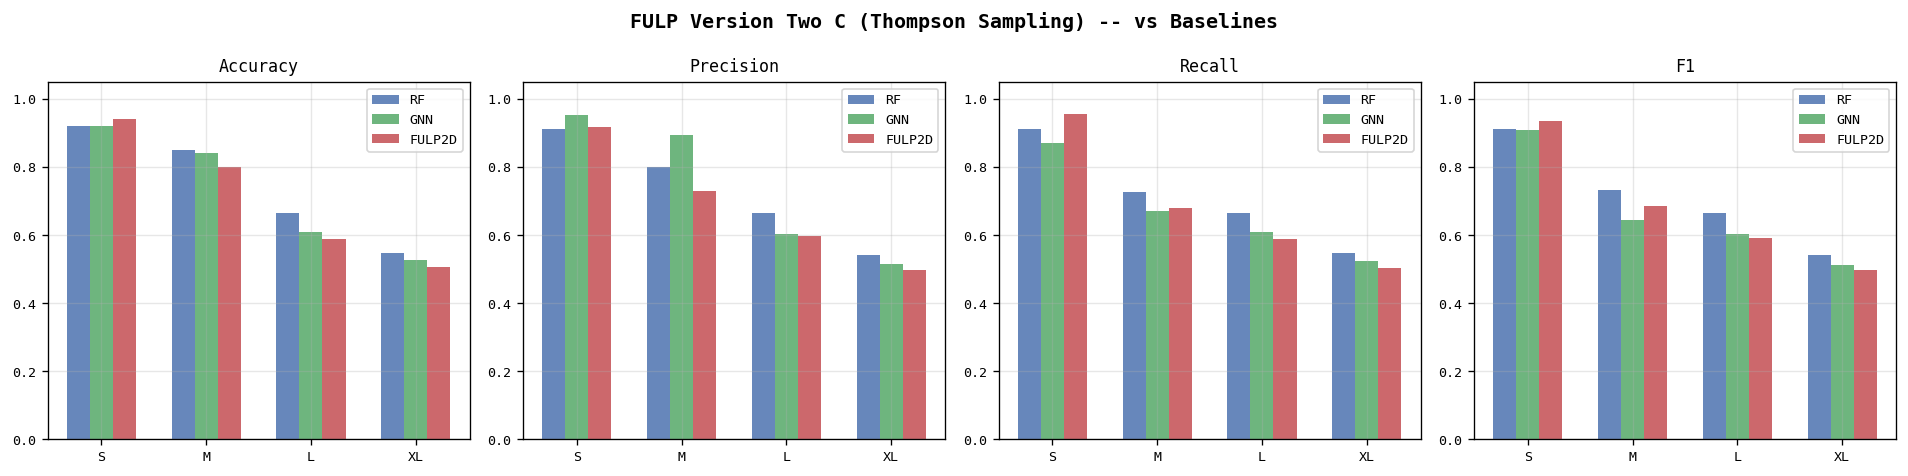

In [ ]:
# ── Cell 13: Accuracy Comparison ────────────────────────────────────────────
x=np.arange(len(tiers)); w=0.22
fig,axes=plt.subplots(1,4,figsize=(16,4))
fig.suptitle('FULP Version Two C (Thompson Sampling) -- vs Baselines',fontweight='bold')
for ax,metric in zip(axes,['accuracy','precision','recall','f1']):
    for i,(model,col) in enumerate([('RF','#4c72b0'),('GNN','#55a868'),('FULP2D','#c44e52')]):
        vals=[RESULTS[t][model.lower()][metric] for t in tiers]
        ax.bar(x+(i-1)*w,vals,w,label=model,color=col,alpha=0.85)
    ax.set_title(metric.capitalize()); ax.set_xticks(x); ax.set_xticklabels(tiers)
    ax.set_ylim(0,1.05); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'v2d_accuracy.png'),bbox_inches='tight'); plt.show()


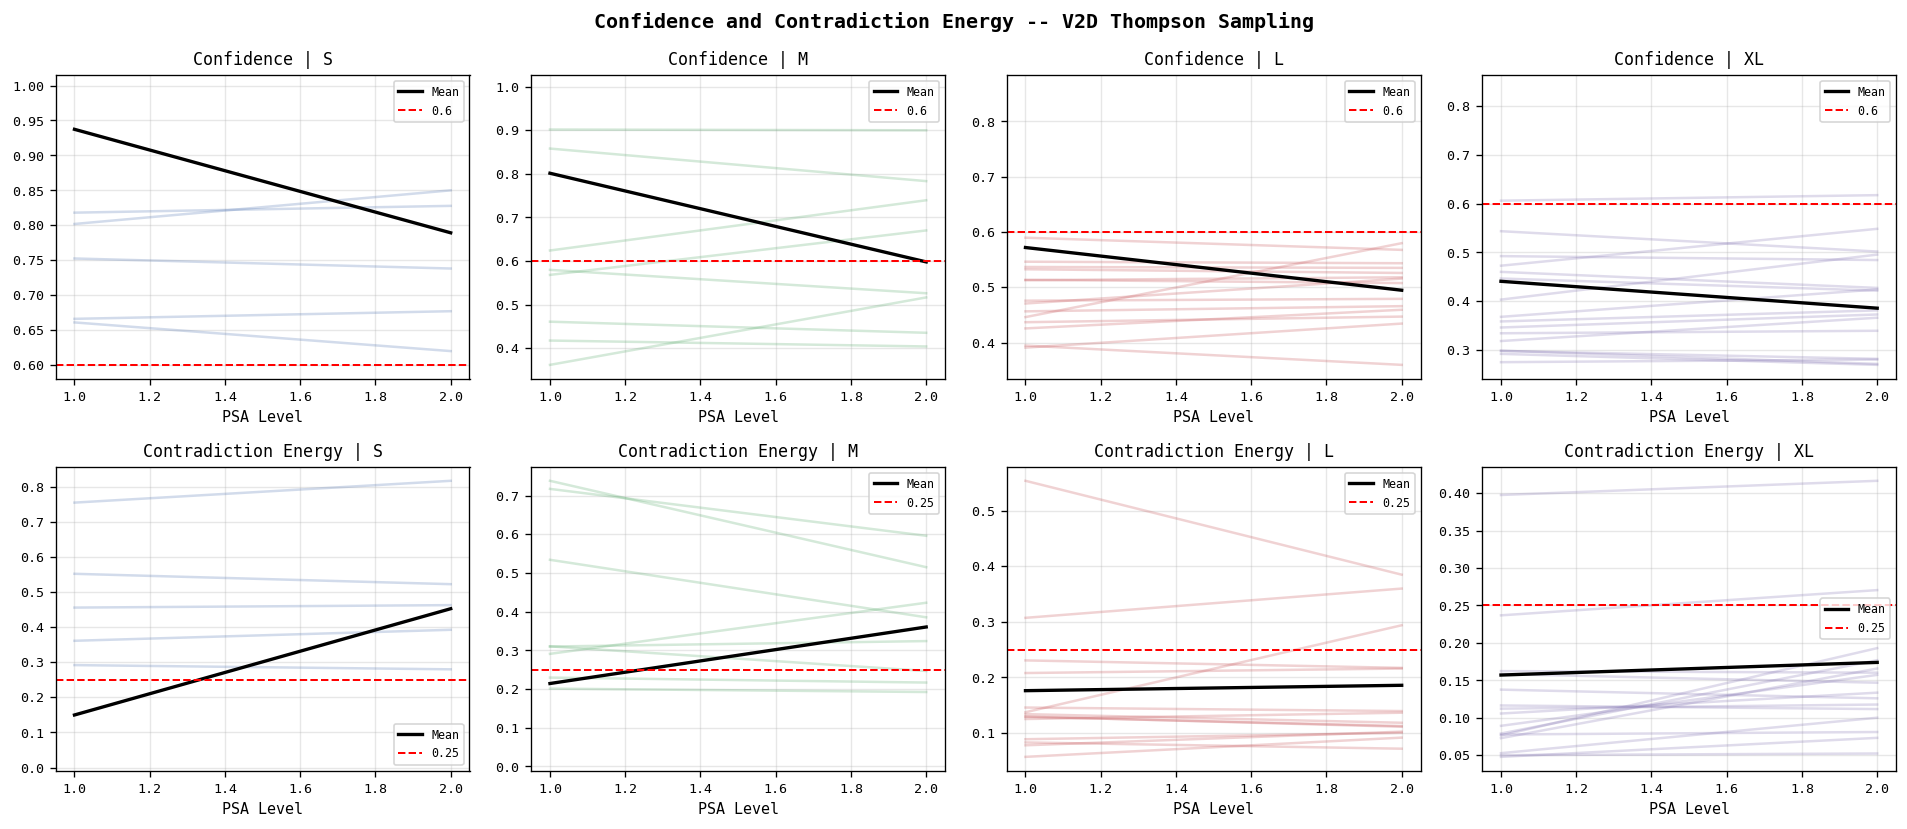

In [ ]:
# ── Cell 14: Confidence & Contradiction Evolution ────────────────────────────
fig,axes=plt.subplots(2,4,figsize=(16,7))
fig.suptitle('Confidence and Contradiction Energy -- V2D Thompson Sampling',fontweight='bold')
for ci,tier in enumerate(tiers):
    all_logs=RESULTS[tier]['all_logs']
    max_len=max((len(lg['confidence_history']) for lg in all_logs if lg['confidence_history']),default=1)
    for log in all_logs[:20]:
        if log['confidence_history']:
            axes[0,ci].plot(range(1,len(log['confidence_history'])+1),
                            log['confidence_history'],alpha=0.25,color=TIER_COLORS[tier])
        if log['contradiction_history']:
            axes[1,ci].plot(range(1,len(log['contradiction_history'])+1),
                            log['contradiction_history'],alpha=0.25,color=TIER_COLORS[tier])
    for ri,(key,thresh,label) in enumerate([
            ('confidence_history',CONF_ACCEPT,'Confidence'),
            ('contradiction_history',CONT_ACCEPT,'Contradiction Energy')]):
        arr=np.full((len(all_logs),max_len),np.nan)
        for i,lg in enumerate(all_logs):
            h=lg[key]; arr[i,:len(h)]=h
        mean_h=np.nanmean(arr,axis=0)
        axes[ri,ci].plot(range(1,max_len+1),mean_h,color='black',lw=2,label='Mean')
        axes[ri,ci].axhline(thresh,color='red',linestyle='--',lw=1.2,label=f'{thresh}')
        axes[ri,ci].set_title(f'{label} | {tier}')
        axes[ri,ci].set_xlabel('PSA Level'); axes[ri,ci].legend(fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'v2d_confidence.png'),bbox_inches='tight'); plt.show()


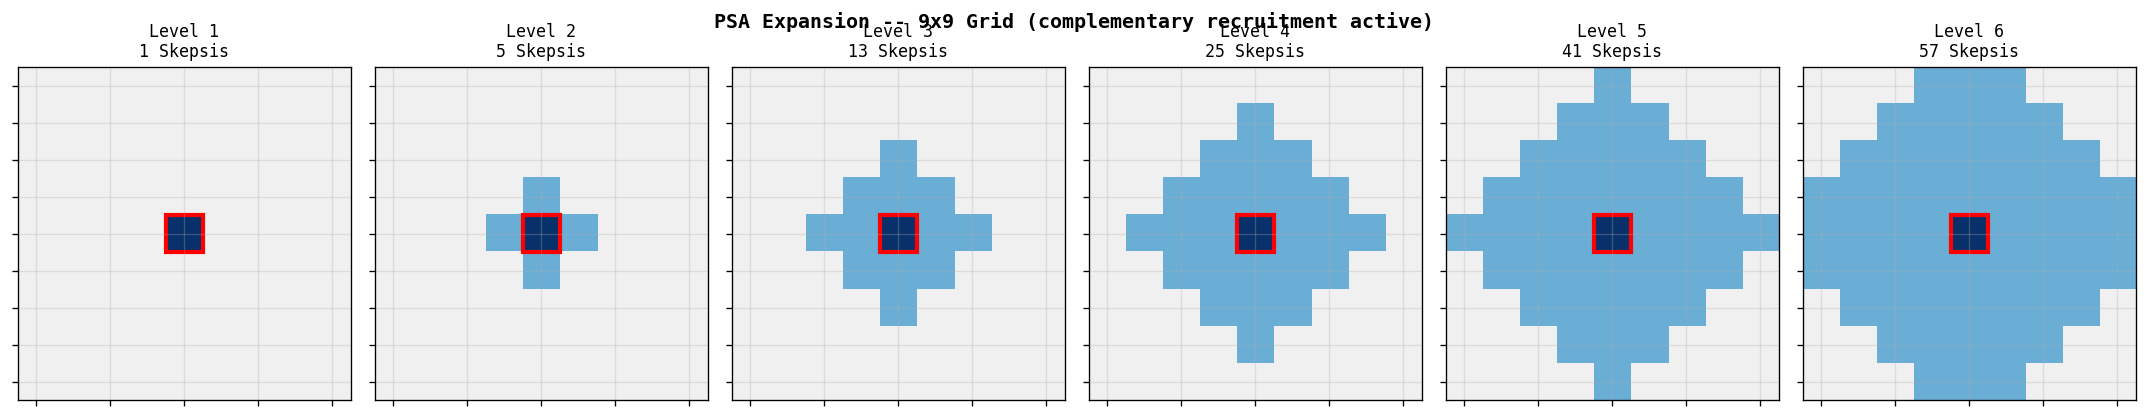

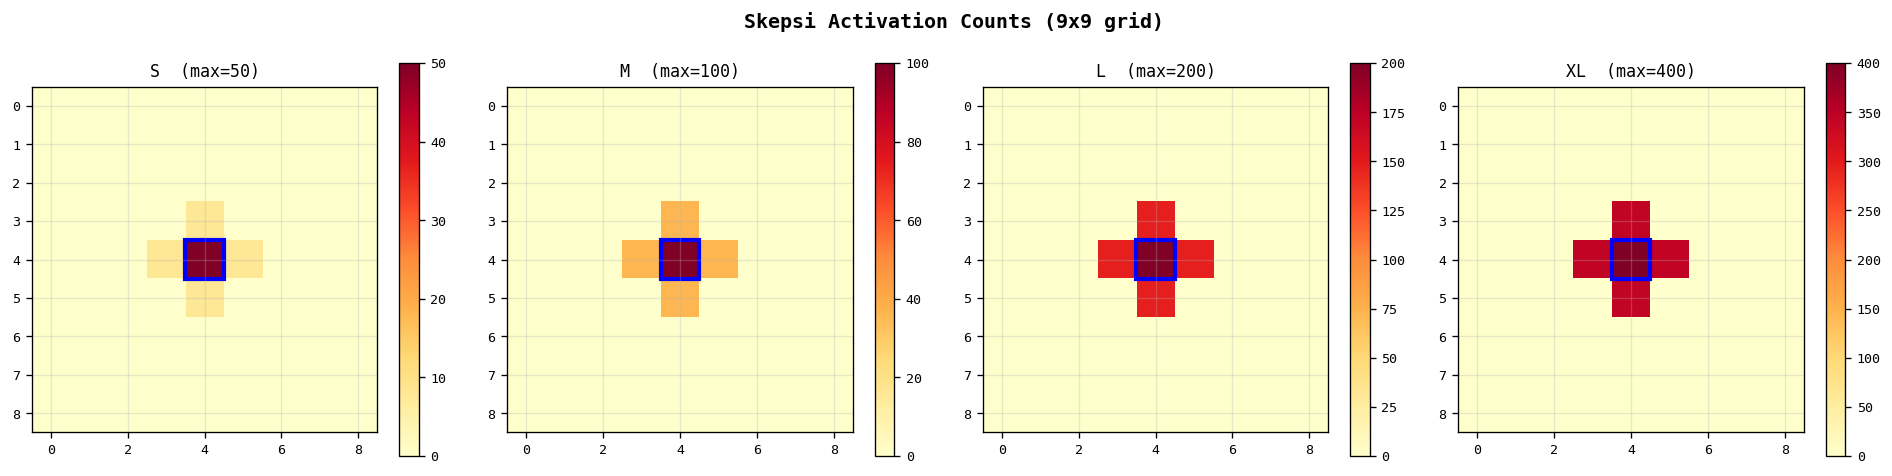

In [ ]:
# ── Cell 15: PSA Expansion + Activation Heatmaps ────────────────────────────
enc_s=RESULTS['S']['enc']; H,W=enc_s.grid_h,enc_s.grid_w; cr,cc=enc_s.center
cmap_psa=LinearSegmentedColormap.from_list('psa',['#f0f0f0','#6baed6','#08306b'])

fig,axes=plt.subplots(1,6,figsize=(18,3.5))
fig.suptitle('PSA Expansion -- 9x9 Grid (complementary recruitment active)',fontweight='bold')
for lv_idx,ax in enumerate(axes):
    level=lv_idx+1; active=set(_vn_up_to(cr,cc,level-1,H,W))
    gi=np.zeros((H,W))
    for (r,c) in active: gi[r,c]=1.0
    gi[cr,cc]=2.0
    ax.imshow(gi,cmap=cmap_psa,vmin=0,vmax=2)
    ax.set_title(f'Level {level}\n{len(active)} Skepsis')
    ax.tick_params(labelbottom=False,labelleft=False)
    ax.add_patch(plt.Rectangle((cc-0.5,cr-0.5),1,1,fill=False,edgecolor='red',lw=2.5))
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'v2d_psa.png'),bbox_inches='tight'); plt.show()

fig,axes=plt.subplots(1,4,figsize=(16,4))
fig.suptitle('Skepsi Activation Counts (9x9 grid)',fontweight='bold')
for ax,tier in zip(axes,tiers):
    hm=RESULTS[tier]['heatmap']; enc=RESULTS[tier]['enc']; cr2,cc2=enc.center
    im=ax.imshow(hm,cmap='YlOrRd'); plt.colorbar(im,ax=ax)
    ax.set_title(f'{tier}  (max={hm.max()})')
    ax.add_patch(plt.Rectangle((cc2-0.5,cr2-0.5),1,1,fill=False,edgecolor='blue',lw=2.5))
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'v2d_activation.png'),bbox_inches='tight'); plt.show()


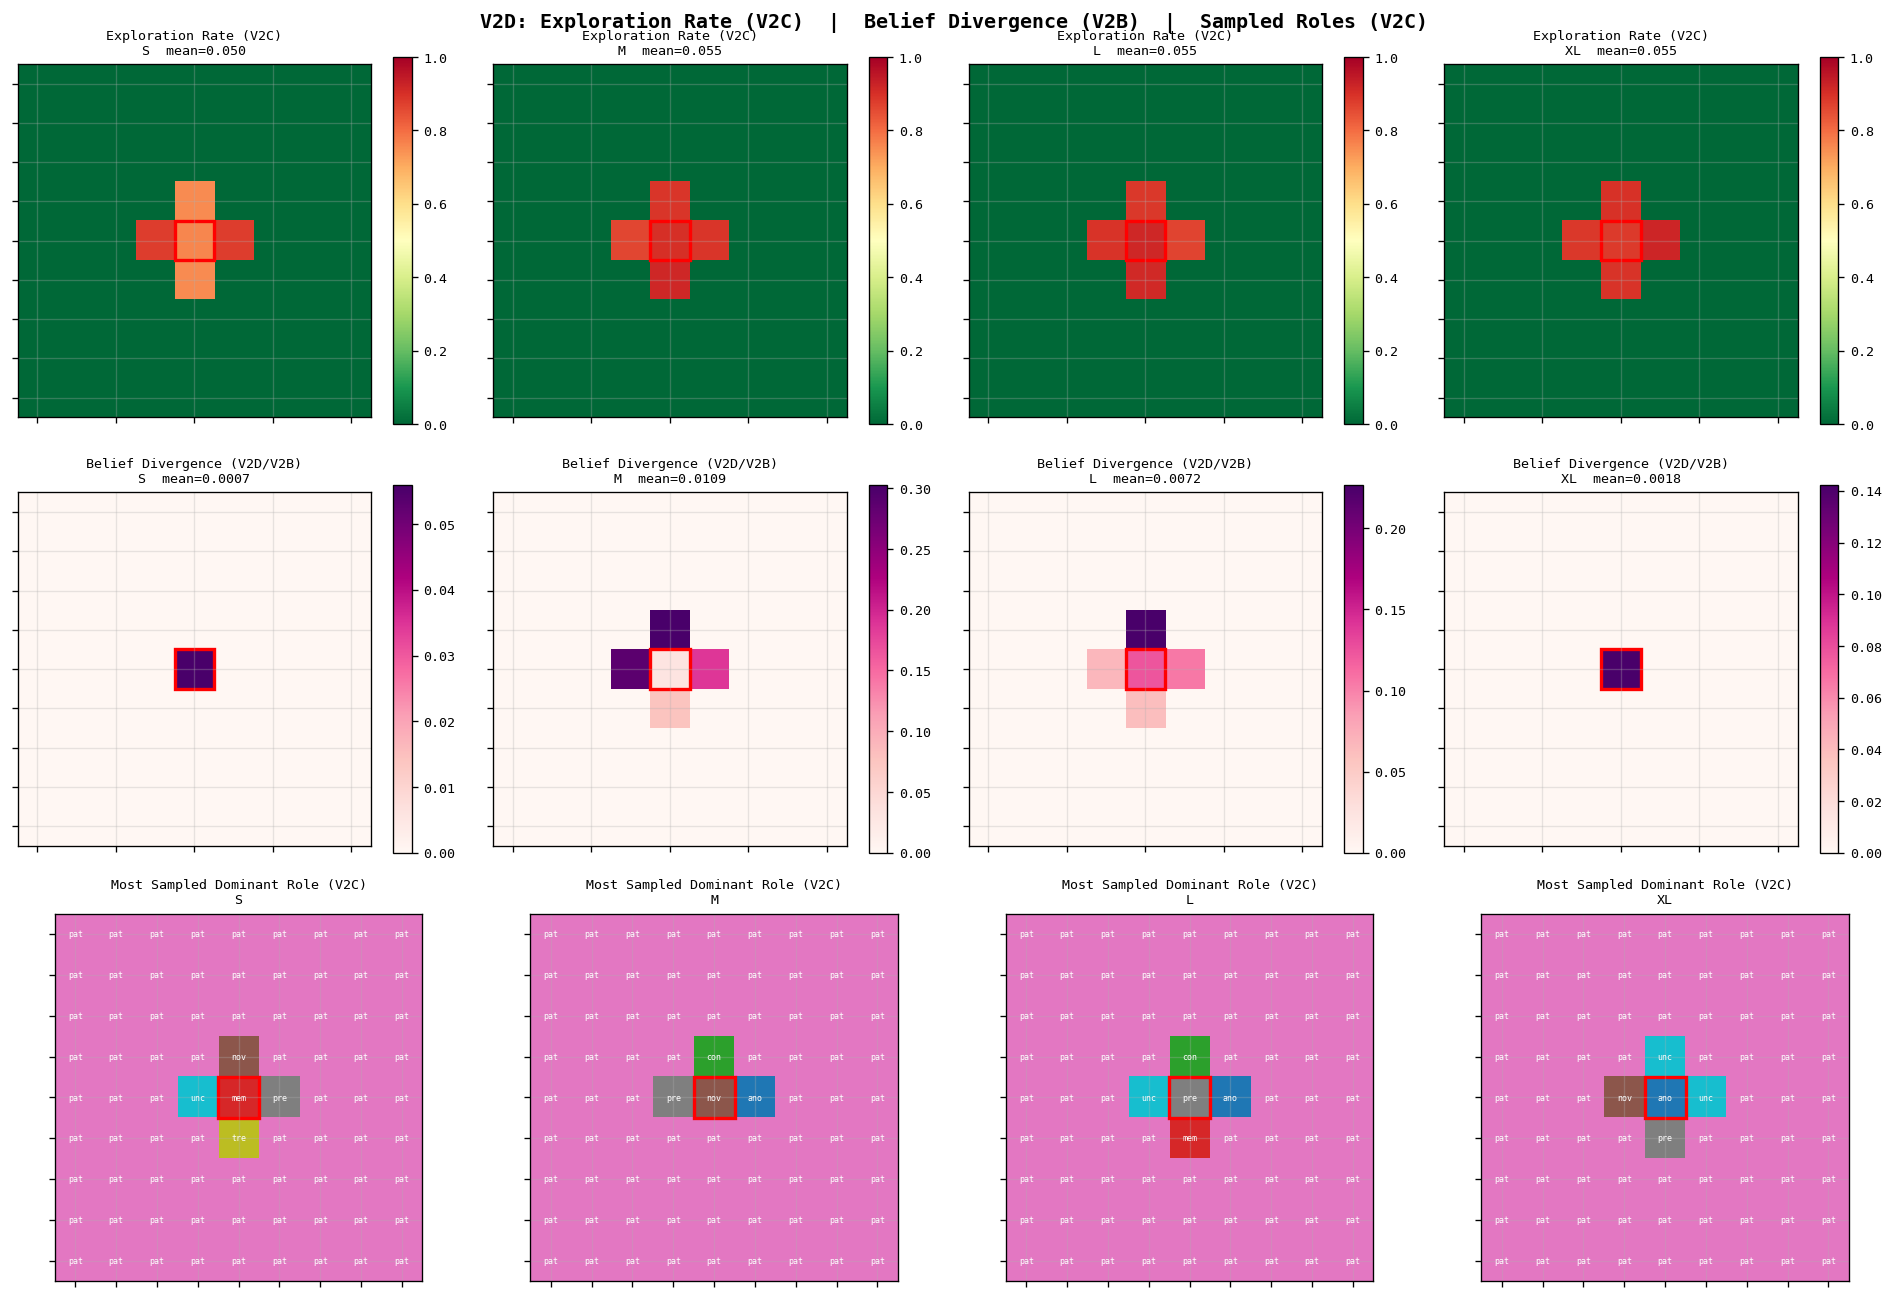

V2D Belief Divergence interpretation:
  High divergence = directed PR significantly moved belief from local evidence
  Low divergence  = Skepsi maintained its local opinion (high rep x confidence)
  S: avg_belief_divergence=0.0007  avg_exploration_rate=0.0495
  M: avg_belief_divergence=0.0109  avg_exploration_rate=0.0550
  L: avg_belief_divergence=0.0072  avg_exploration_rate=0.0551
  XL: avg_belief_divergence=0.0018  avg_exploration_rate=0.0552


In [ ]:
# ── Cell 16: V2D — Exploration Rate, Belief Divergence, Sampled Roles ────────
#
# Panel 1 (V2C, preserved): Exploration rate per Skepsi
# Panel 2 (V2D from V2B):   Belief divergence — how far directed peer review
#                            moved each Skepsi from its local evidence
# Panel 3 (V2C, preserved): Most-sampled dominant role per Skepsi

fig,axes=plt.subplots(3,4,figsize=(16,11))
fig.suptitle('V2D: Exploration Rate (V2C)  |  Belief Divergence (V2B)  |  Sampled Roles (V2C)',
             fontweight='bold')

for ci,tier in enumerate(tiers):
    enc=RESULTS[tier]['enc']; cr,cc=enc.center

    # Row 0: Exploration rate (V2C — unchanged)
    ax=axes[0,ci]; hm=RESULTS[tier]['explore_heatmap']
    im=ax.imshow(hm,cmap='RdYlGn_r',vmin=0,vmax=1)
    plt.colorbar(im,ax=ax)
    ax.set_title(f'Exploration Rate (V2C)\n{tier}  mean={hm.mean():.3f}',fontsize=8)
    ax.add_patch(plt.Rectangle((cc-0.5,cr-0.5),1,1,fill=False,edgecolor='red',lw=2))
    ax.tick_params(labelbottom=False,labelleft=False)

    # ----- V2D addition: belief divergence heatmap (from V2B) -----
    ax=axes[1,ci]; hm=RESULTS[tier]['belief_div_heatmap']
    im=ax.imshow(hm,cmap='RdPu',vmin=0,vmax=max(hm.max(),0.01))
    plt.colorbar(im,ax=ax)
    ax.set_title(f'Belief Divergence (V2D/V2B)\n{tier}  mean={hm.mean():.4f}',fontsize=8)
    ax.add_patch(plt.Rectangle((cc-0.5,cr-0.5),1,1,fill=False,edgecolor='red',lw=2))
    ax.tick_params(labelbottom=False,labelleft=False)
    # ----- end V2D addition -----

    # Row 2: Sampled dominant role (V2C — unchanged)
    ax=axes[2,ci]
    dom_grid=RESULTS[tier]['sampled_dom_grid']
    role_to_int={r:i for i,r in enumerate(sorted(ROLE_COLORS))}
    dm=np.array([[role_to_int[dom_grid[r][c]] for c in range(enc.grid_w)]
                  for r in range(enc.grid_h)])
    ax.imshow(dm,cmap=plt.cm.get_cmap('tab10',len(ROLE_COLORS)),vmin=0,vmax=len(ROLE_COLORS)-1)
    ax.set_title(f'Most Sampled Dominant Role (V2C)\n{tier}',fontsize=8)
    for r in range(enc.grid_h):
        for c in range(enc.grid_w):
            dom=dom_grid[r][c]
            ax.text(c,r,dom[:3],ha='center',va='center',fontsize=5,color='white')
    ax.add_patch(plt.Rectangle((cc-0.5,cr-0.5),1,1,fill=False,edgecolor='red',lw=2))
    ax.tick_params(labelbottom=False,labelleft=False)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'v2d_exploration_divergence.png'),bbox_inches='tight')
plt.show()

print('V2D Belief Divergence interpretation:')
print('  High divergence = directed PR significantly moved belief from local evidence')
print('  Low divergence  = Skepsi maintained its local opinion (high rep x confidence)')
for tier in tiers:
    f=RESULTS[tier]['fulp2d']
    print(f'  {tier}: avg_belief_divergence={f.get("avg_belief_divergence",0):.4f}  '
          f'avg_exploration_rate={f["avg_exploration_rate"]:.4f}')


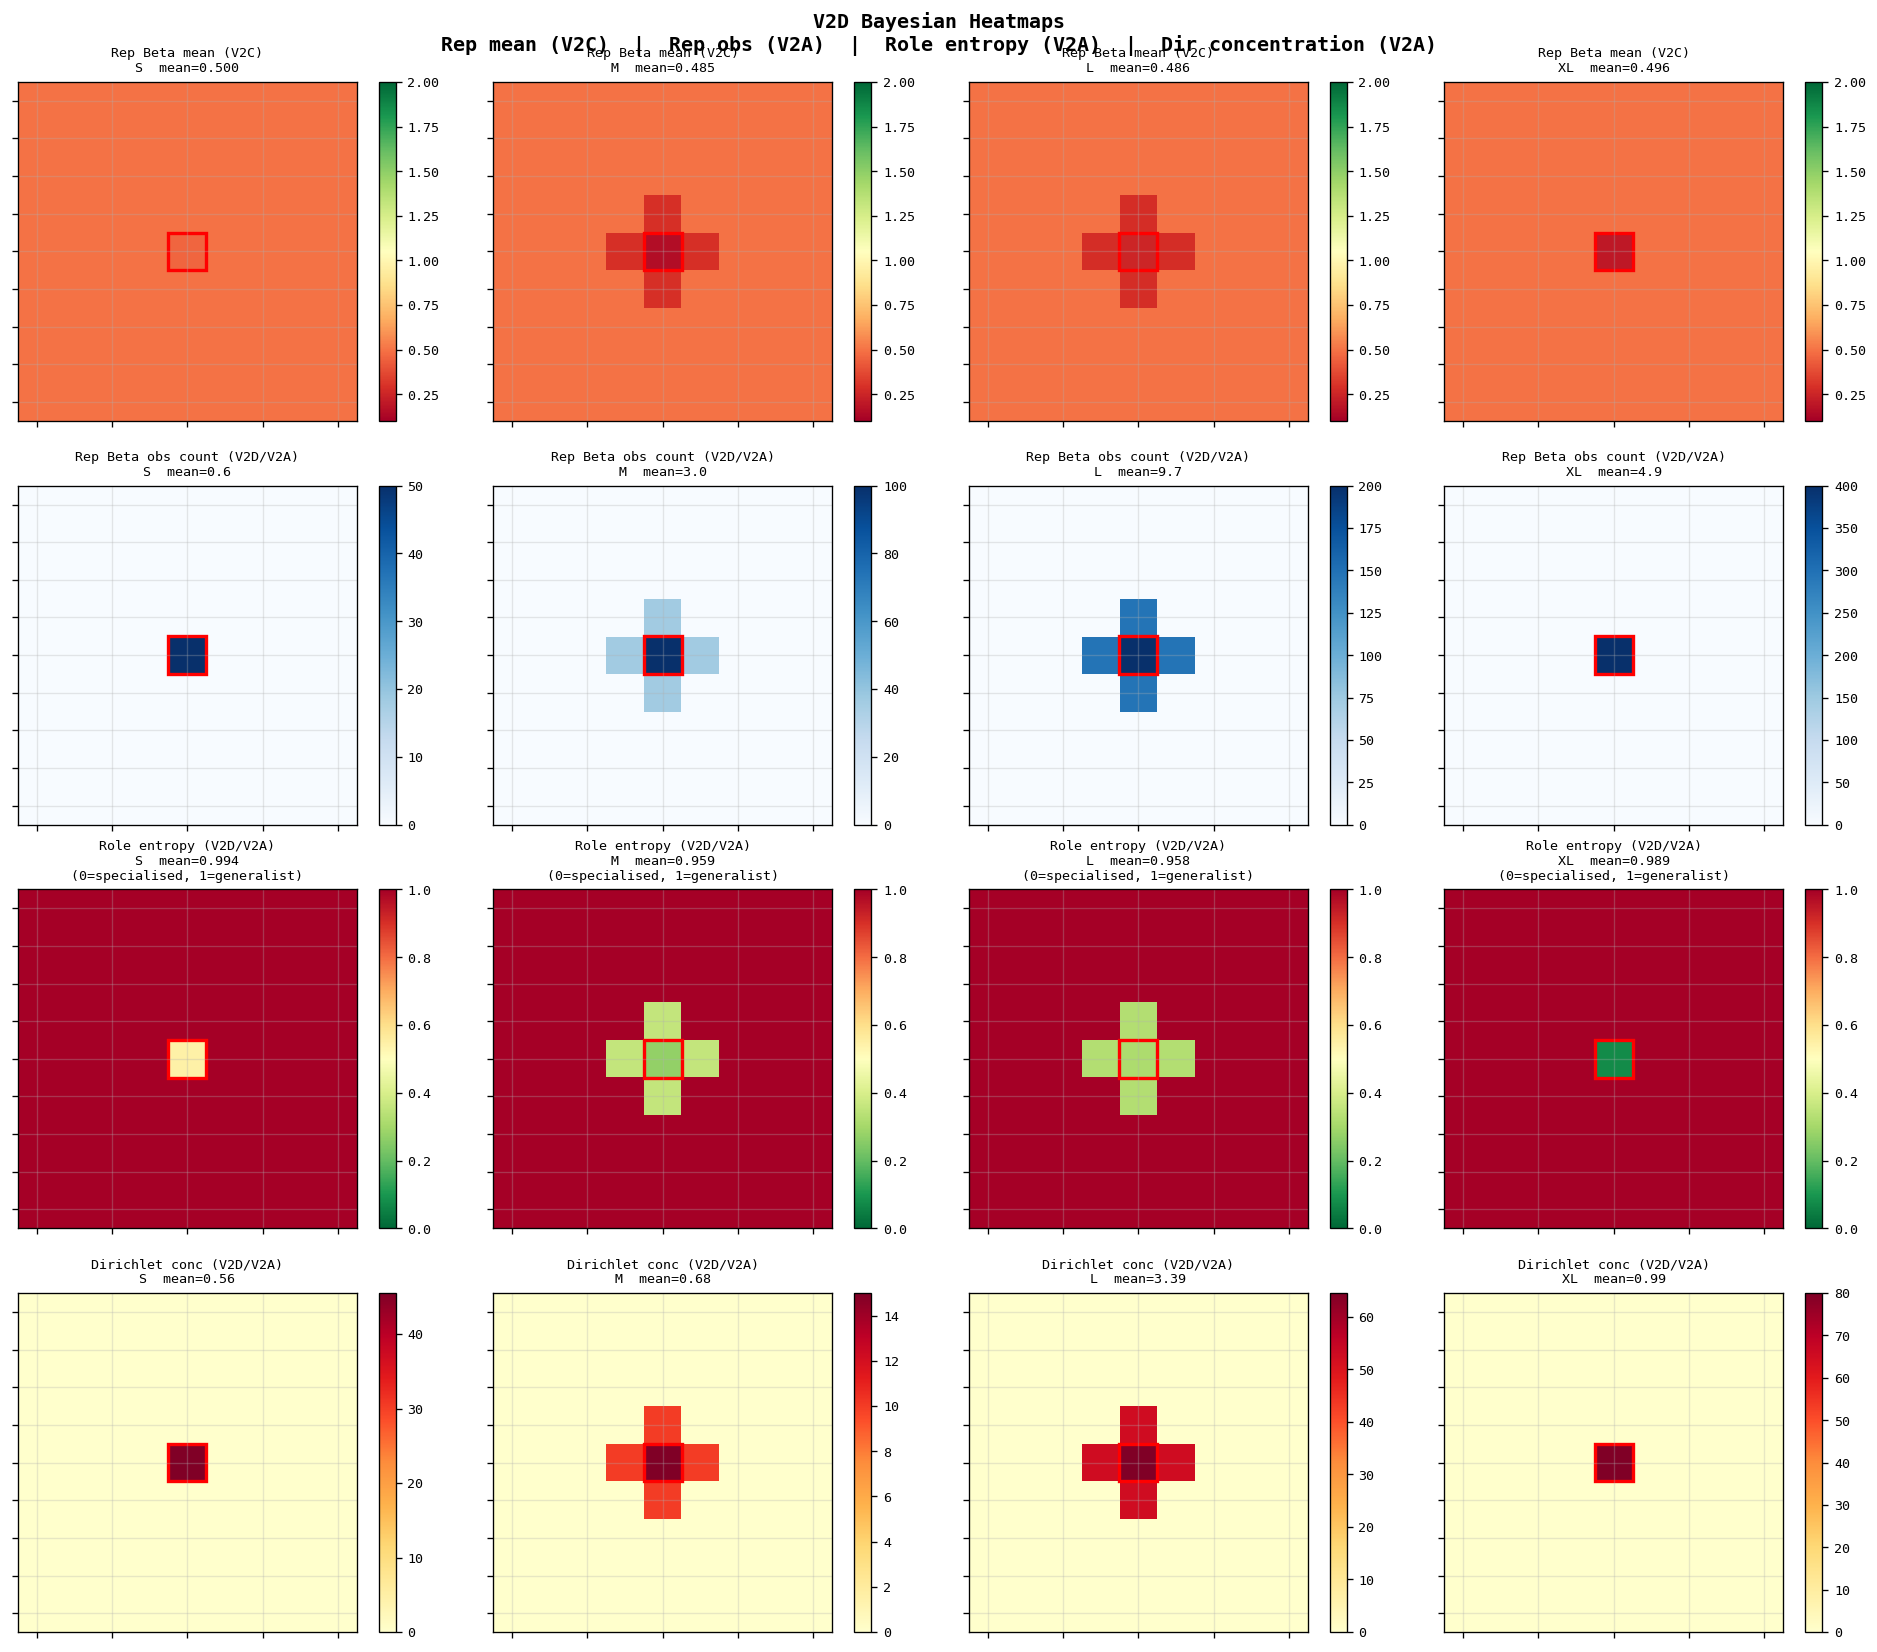

V2D Bayesian Summary:
Tier    Rep mean    Rep obs  Explore rt     Role H   Dir conc    Bel div
--------------------------------------------------------------------
S         0.4995        0.6      0.0495     0.9944       0.56     0.0007
M         0.4854        3.0      0.0550     0.9593       0.68     0.0109
L         0.4862        9.7      0.0551     0.9583       3.39     0.0072
XL        0.4963        4.9      0.0552     0.9886       0.99     0.0018


In [ ]:
# ── Cell 17: V2D — Bayesian Distribution Heatmaps (V2A + V2B additions) ──────
#
# Row 0 (V2C): Reputation Beta mean — unchanged
# Row 1 (V2D from V2A): Reputation Beta concentration — how many observations
# Row 2 (V2D from V2A): Role Dirichlet entropy — specialisation level
# Row 3 (V2D from V2A): Dirichlet concentration — total role evidence

fig,axes=plt.subplots(4,4,figsize=(16,14))
fig.suptitle('V2D Bayesian Heatmaps\n'
             'Rep mean (V2C)  |  Rep obs (V2A)  |  Role entropy (V2A)  |  Dir concentration (V2A)',
             fontweight='bold')

for ci,tier in enumerate(tiers):
    enc=RESULTS[tier]['enc']; cr,cc=enc.center

    # Row 0: Reputation mean (V2C — unchanged)
    ax=axes[0,ci]; hm=RESULTS[tier]['rep_heatmap']
    im=ax.imshow(hm,cmap='RdYlGn',vmin=0.1,vmax=2.0)
    plt.colorbar(im,ax=ax)
    ax.set_title(f'Rep Beta mean (V2C)\n{tier}  mean={hm.mean():.3f}',fontsize=8)
    ax.add_patch(plt.Rectangle((cc-0.5,cr-0.5),1,1,fill=False,edgecolor='red',lw=2))
    ax.tick_params(labelbottom=False,labelleft=False)

    # ----- V2D addition (from V2A): reputation concentration -----
    ax=axes[1,ci]; hm=RESULTS[tier]['rep_conc_heatmap']
    im=ax.imshow(hm,cmap='Blues',vmin=0,vmax=max(hm.max(),1))
    plt.colorbar(im,ax=ax)
    ax.set_title(f'Rep Beta obs count (V2D/V2A)\n{tier}  mean={hm.mean():.1f}',fontsize=8)
    ax.add_patch(plt.Rectangle((cc-0.5,cr-0.5),1,1,fill=False,edgecolor='red',lw=2))
    ax.tick_params(labelbottom=False,labelleft=False)

    # ----- V2D addition (from V2A): role entropy -----
    ax=axes[2,ci]; hm=RESULTS[tier]['role_ent_heatmap']
    im=ax.imshow(hm,cmap='RdYlGn_r',vmin=0,vmax=1)
    plt.colorbar(im,ax=ax)
    ax.set_title(f'Role entropy (V2D/V2A)\n{tier}  mean={hm.mean():.3f}\n(0=specialised, 1=generalist)',fontsize=8)
    ax.add_patch(plt.Rectangle((cc-0.5,cr-0.5),1,1,fill=False,edgecolor='red',lw=2))
    ax.tick_params(labelbottom=False,labelleft=False)

    # ----- V2D addition (from V2A): Dirichlet concentration -----
    ax=axes[3,ci]; hm=RESULTS[tier]['dir_conc_heatmap']
    im=ax.imshow(hm,cmap='YlOrRd',vmin=0,vmax=max(hm.max(),0.1))
    plt.colorbar(im,ax=ax)
    ax.set_title(f'Dirichlet conc (V2D/V2A)\n{tier}  mean={hm.mean():.2f}',fontsize=8)
    ax.add_patch(plt.Rectangle((cc-0.5,cr-0.5),1,1,fill=False,edgecolor='red',lw=2))
    ax.tick_params(labelbottom=False,labelleft=False)
    # ----- end V2D additions -----

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'v2d_bayesian_heatmaps.png'),bbox_inches='tight')
plt.show()

# Sanity check print
print('V2D Bayesian Summary:')
fmt='{:<5}  {:>9}  {:>9}  {:>10}  {:>9}  {:>9}  {:>9}'
print(fmt.format('Tier','Rep mean','Rep obs','Explore rt','Role H','Dir conc','Bel div'))
print('-'*68)
for tier in tiers:
    f=RESULTS[tier]['fulp2d']
    print(fmt.format(
        tier,
        f'{f["rep_mean"]:.4f}',
        f'{f.get("rep_avg_concentration",0):.1f}',
        f'{f["avg_exploration_rate"]:.4f}',
        f'{f.get("role_entropy_mean",0):.4f}',
        f'{f.get("role_dirichlet_concentration",0):.2f}',
        f'{f.get("avg_belief_divergence",0):.4f}',
    ))


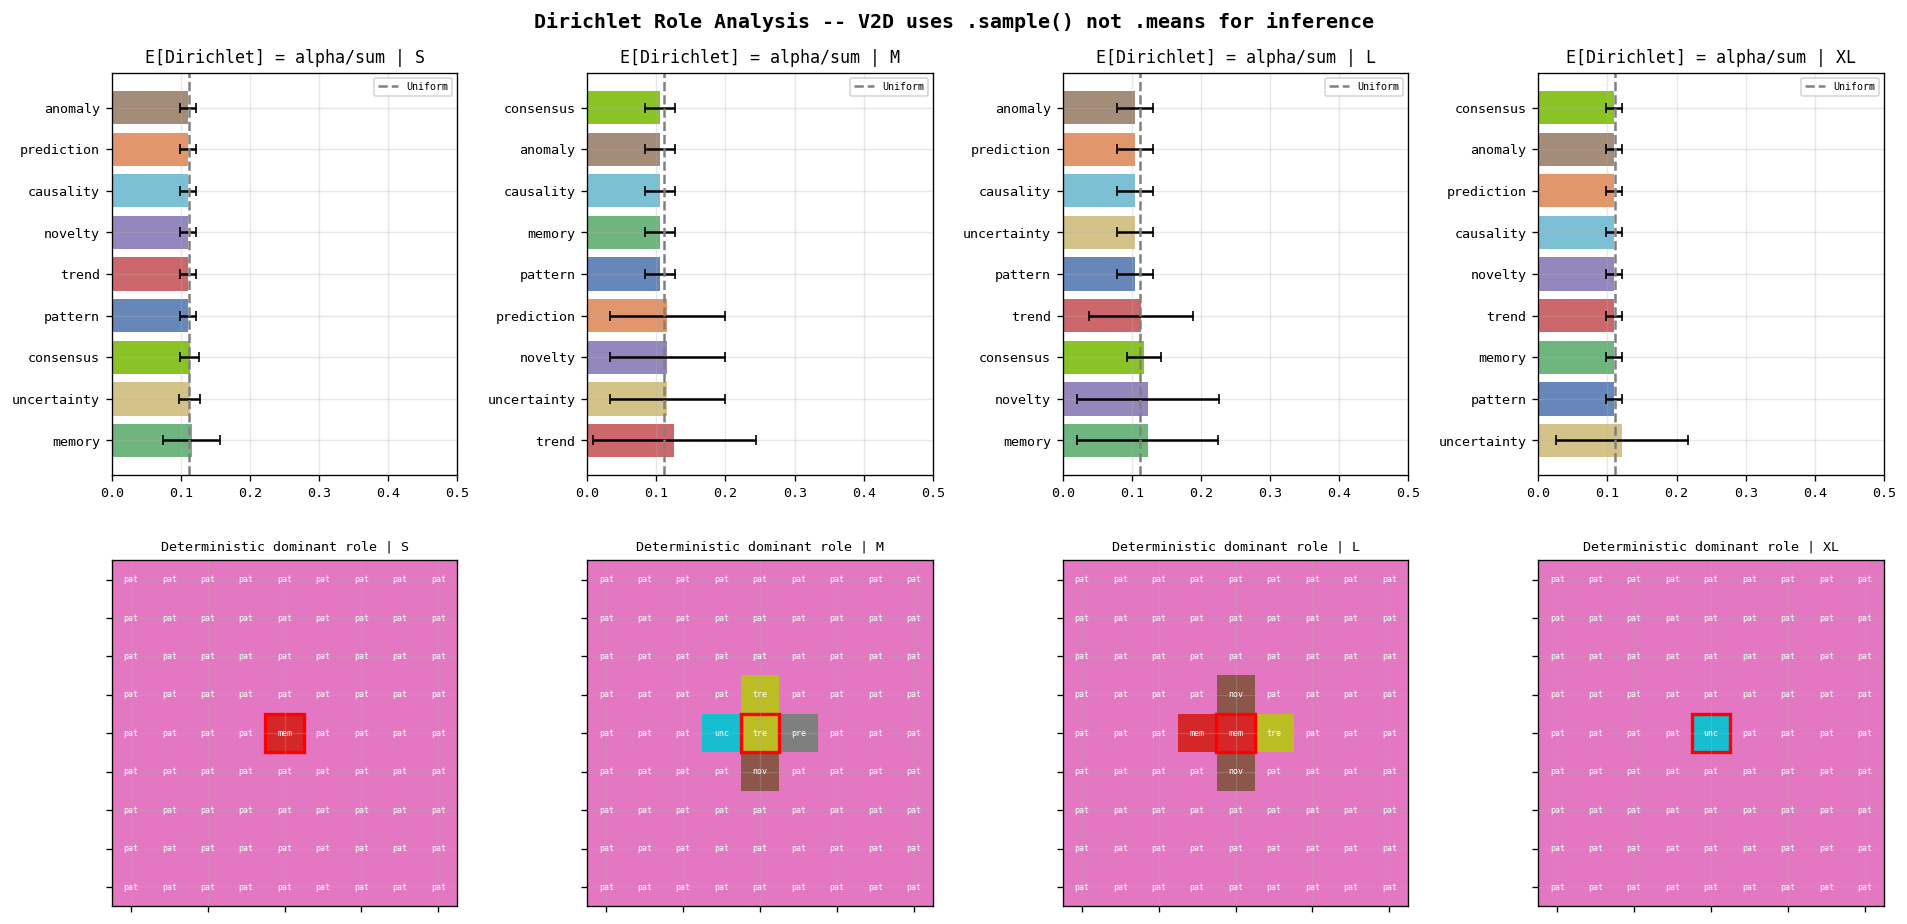

In [ ]:
# ── Cell 18: Dirichlet Role Analysis ─────────────────────────────────────────
fig,axes=plt.subplots(2,4,figsize=(16,8))
fig.suptitle('Dirichlet Role Analysis -- V2D uses .sample() not .means for inference',
             fontweight='bold')
for ci,tier in enumerate(tiers):
    enc=RESULTS[tier]['enc']; cr,cc=enc.center
    rv_means=enc.role_means_grid(); rv_stds=enc.role_stds_grid()

    ax=axes[0,ci]
    roles_s=sorted(rv_means,key=rv_means.get,reverse=True)
    ax.barh(roles_s,[rv_means[r] for r in roles_s],
            xerr=[rv_stds[r] for r in roles_s],
            color=[ROLE_COLORS[r] for r in roles_s],alpha=0.85,capsize=3)
    ax.axvline(1/len(ALL_ROLES),color='grey',linestyle='--',lw=1.5,label='Uniform')
    ax.set_title(f'E[Dirichlet] = alpha/sum | {tier}'); ax.set_xlim(0,0.5); ax.legend(fontsize=6)

    ax=axes[1,ci]
    dom_grid=enc.dominant_role_grid()
    r2i={r:i for i,r in enumerate(sorted(ROLE_COLORS))}
    dm=np.array([[r2i[dom_grid[r][c]] for c in range(enc.grid_w)] for r in range(enc.grid_h)])
    ax.imshow(dm,cmap=plt.cm.get_cmap('tab10',len(ROLE_COLORS)),vmin=0,vmax=len(ROLE_COLORS)-1)
    ax.set_title(f'Deterministic dominant role | {tier}',fontsize=8)
    for r in range(enc.grid_h):
        for c in range(enc.grid_w):
            dom=dom_grid[r][c]
            ax.text(c,r,dom[:3],ha='center',va='center',fontsize=5,color='white')
    ax.add_patch(plt.Rectangle((cc-0.5,cr-0.5),1,1,fill=False,edgecolor='red',lw=2))
    ax.tick_params(labelbottom=False,labelleft=False)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'v2d_roles.png'),bbox_inches='tight'); plt.show()


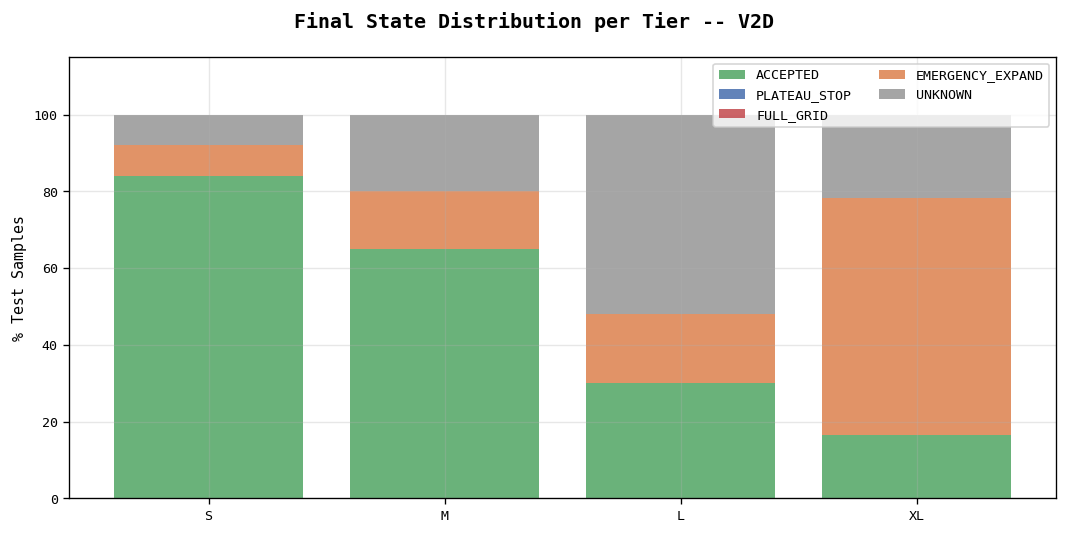

In [ ]:
# ── Cell 19: State Transitions ───────────────────────────────────────────────
states=['ACCEPTED','PLATEAU_STOP','FULL_GRID','EMERGENCY_EXPAND','UNKNOWN']
sc_colors={'ACCEPTED':'#55a868','PLATEAU_STOP':'#4c72b0','FULL_GRID':'#c44e52',
           'EMERGENCY_EXPAND':'#dd8452','UNKNOWN':'#999999'}
fig,ax=plt.subplots(figsize=(9,4.5))
fig.suptitle('Final State Distribution per Tier -- V2D',fontweight='bold')
x=np.arange(len(tiers)); bottoms=np.zeros(len(tiers))
n_samples=[RESULTS[t]['n_test'] for t in tiers]
for state in states:
    vals=[RESULTS[t]['fulp2d'].get('state_counts',{}).get(state,0)/n*100
          for t,n in zip(tiers,n_samples)]
    ax.bar(x,vals,bottom=bottoms,label=state,color=sc_colors[state],alpha=0.88)
    bottoms+=np.array(vals)
ax.set_xticks(x); ax.set_xticklabels(tiers); ax.set_ylabel('% Test Samples')
ax.set_ylim(0,115); ax.legend(loc='upper right',ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'v2d_states.png'),bbox_inches='tight'); plt.show()


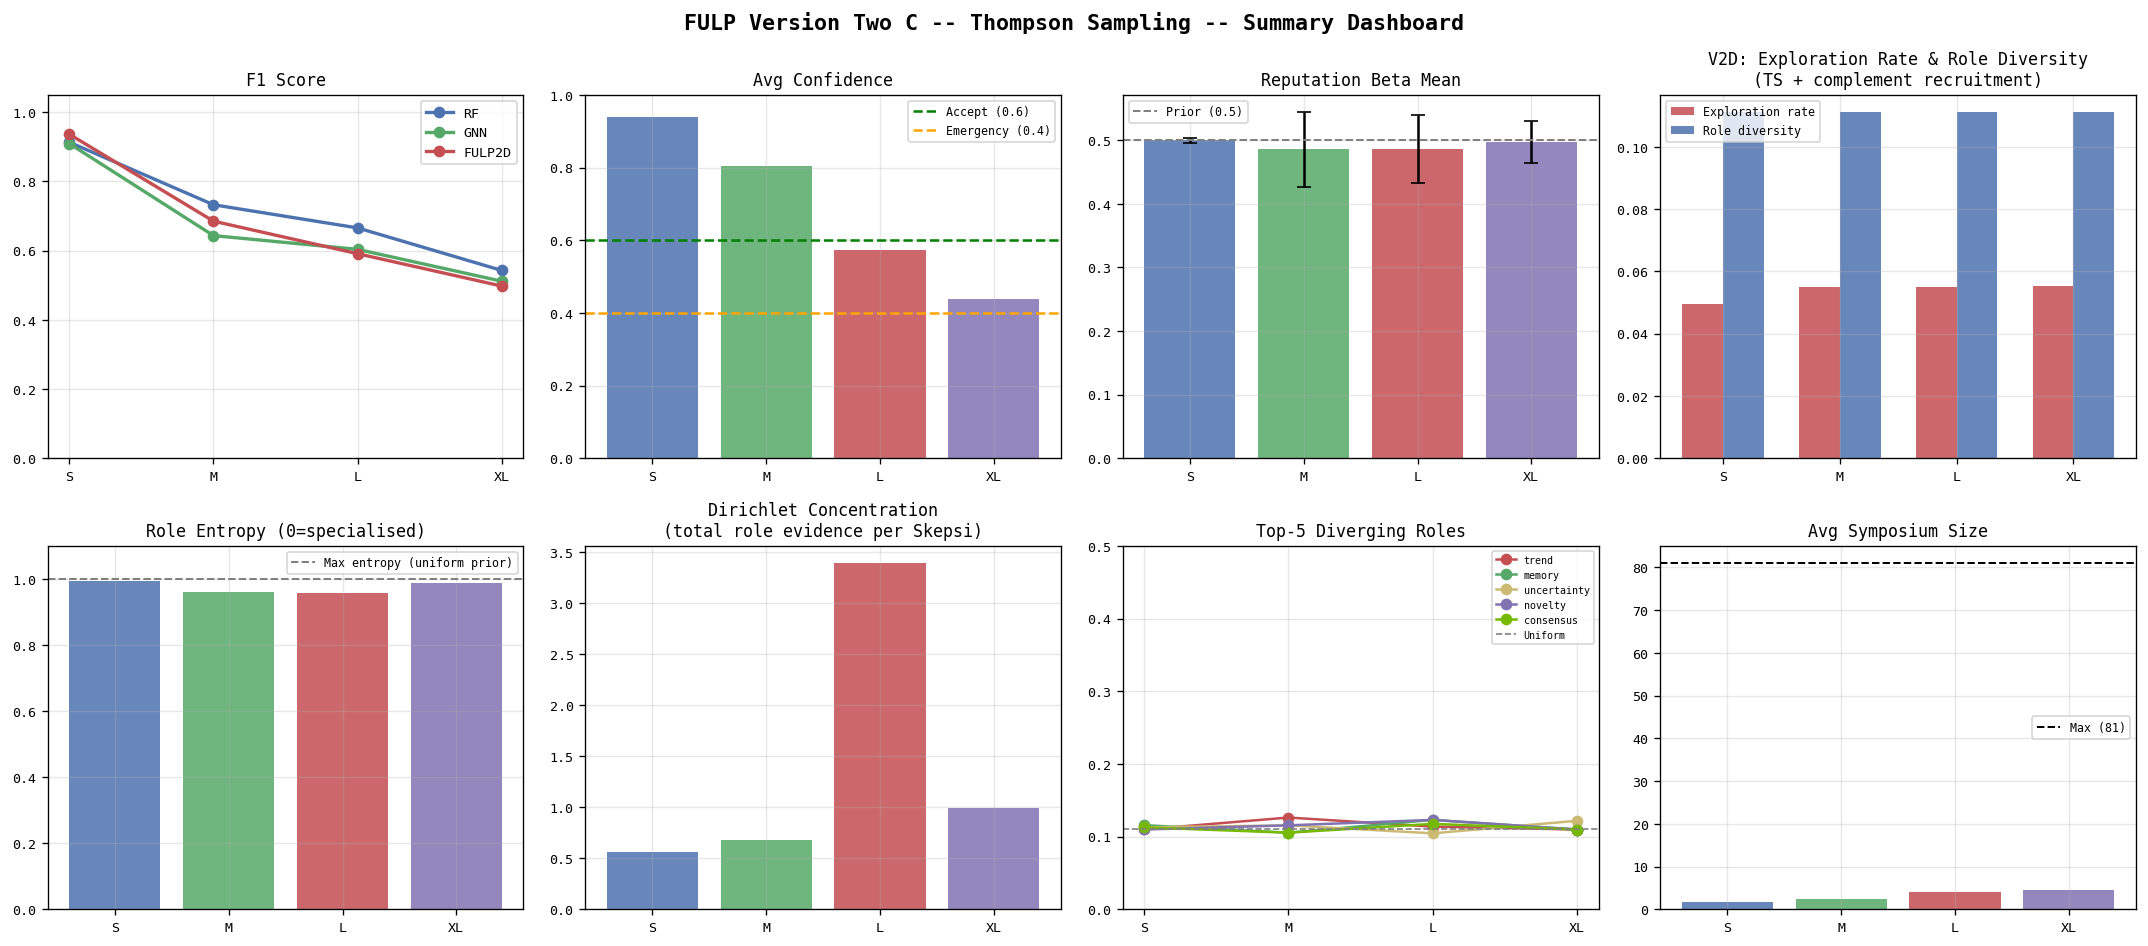

In [ ]:
# ── Cell 20: Summary Dashboard ──────────────────────────────────────────────
fig,axes=plt.subplots(2,4,figsize=(18,8))
fig.suptitle('FULP Version Two C -- Thompson Sampling -- Summary Dashboard',
             fontweight='bold',fontsize=13)

ax=axes[0,0]
for model,col in [('RF','#4c72b0'),('GNN','#55a868'),('FULP2D','#c44e52')]:
    vals=[RESULTS[t][model.lower()]['f1'] for t in tiers]
    ax.plot(tiers,vals,'o-',color=col,label=model,lw=2)
ax.set_title('F1 Score'); ax.set_ylim(0,1.05); ax.legend()

ax=axes[0,1]
confs=[RESULTS[t]['fulp2d']['avg_confidence'] for t in tiers]
ax.bar(tiers,confs,color=[TIER_COLORS[t] for t in tiers],alpha=0.85)
ax.axhline(CONF_ACCEPT,color='green',linestyle='--',lw=1.5,label=f'Accept ({CONF_ACCEPT})')
ax.axhline(CONF_EMERGENCY,color='orange',linestyle='--',lw=1.5,label=f'Emergency ({CONF_EMERGENCY})')
ax.set_title('Avg Confidence'); ax.set_ylim(0,1); ax.legend(fontsize=7)

ax=axes[0,2]
rm=[RESULTS[t]['fulp2d']['rep_mean'] for t in tiers]
rs=[RESULTS[t]['fulp2d']['rep_std']  for t in tiers]
ax.bar(tiers,rm,color=[TIER_COLORS[t] for t in tiers],alpha=0.85)
ax.errorbar(tiers,rm,rs,fmt='none',color='black',capsize=4)
ax.axhline(0.5,color='grey',linestyle='--',lw=1.2,label='Prior (0.5)')
ax.set_title('Reputation Beta Mean'); ax.legend(fontsize=7)

ax=axes[0,3]
er=[RESULTS[t]['fulp2d']['avg_exploration_rate'] for t in tiers]
rd=[RESULTS[t]['fulp2d']['avg_role_diversity']   for t in tiers]
x2=np.arange(len(tiers)); w=0.35
ax.bar(x2-w/2,er,w,label='Exploration rate',color='#c44e52',alpha=0.85)
ax.bar(x2+w/2,rd,w,label='Role diversity',  color='#4c72b0',alpha=0.85)
ax.set_title('V2D: Exploration Rate & Role Diversity\n(TS + complement recruitment)')
ax.set_xticks(x2); ax.set_xticklabels(tiers); ax.legend(fontsize=7)

ax=axes[1,0]
entropies=[RESULTS[t]['fulp2d']['role_entropy_mean'] for t in tiers]
ax.bar(tiers,entropies,color=[TIER_COLORS[t] for t in tiers],alpha=0.85)
ax.axhline(1.0,color='grey',linestyle='--',lw=1.2,label='Max entropy (uniform prior)')
ax.set_title('Role Entropy (0=specialised)'); ax.set_ylim(0,1.1); ax.legend(fontsize=7)

ax=axes[1,1]
concs=[RESULTS[t]['fulp2d']['role_dirichlet_concentration_mean'] for t in tiers]
ax.bar(tiers,concs,color=[TIER_COLORS[t] for t in tiers],alpha=0.85)
ax.set_title('Dirichlet Concentration\n(total role evidence per Skepsi)')

ax=axes[1,2]
all_rv={role:[RESULTS[t]['fulp2d']['role_means'][role] for t in tiers] for role in ALL_ROLES}
for role in sorted(ALL_ROLES,key=lambda r:np.std([RESULTS[t]['fulp2d']['role_means'][r] for t in tiers]),reverse=True)[:5]:
    ax.plot(tiers,all_rv[role],'o-',label=role,color=ROLE_COLORS[role],lw=1.5)
ax.axhline(1/len(ALL_ROLES),color='grey',linestyle='--',lw=1,label='Uniform')
ax.set_title('Top-5 Diverging Roles'); ax.set_ylim(0,0.5); ax.legend(fontsize=6)

ax=axes[1,3]
sym=[RESULTS[t]['fulp2d']['avg_symposium_size'] for t in tiers]
ax.bar(tiers,sym,color=[TIER_COLORS[t] for t in tiers],alpha=0.85)
ax.axhline(GRID_H*GRID_W,color='black',linestyle='--',lw=1.2,label=f'Max ({GRID_H*GRID_W})')
ax.set_title('Avg Symposium Size'); ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'v2d_dashboard.png'),bbox_inches='tight'); plt.show()


In [ ]:
# ── Cell 21: V2D Final Summary and Synthesis Report ─────────────────────────
print('\nFULPs -- Version Two D (Evolutionary Synthesis) -- Final Summary')
print('='*76)
fmt='{:<8}  {:>8}  {:>8}  {:>8}  {:>8}  {:>8}  {:>8}  {:>9}'
print(fmt.format('Tier','RF Acc','GNN Acc','V2D Acc','RF F1','GNN F1','V2D F1','Avg Conf'))
print('-'*76)
for tier in tiers:
    r=RESULTS[tier]
    print(fmt.format(tier,
        f'{r["rf"]["accuracy"]:.4f}',f'{r["gnn"]["accuracy"]:.4f}',
        f'{r["fulp2d"]["accuracy"]:.4f}',
        f'{r["rf"]["f1"]:.4f}',f'{r["gnn"]["f1"]:.4f}',
        f'{r["fulp2d"]["f1"]:.4f}',f'{r["fulp2d"]["avg_confidence"]:.4f}'))
print('='*76)

print('\nV2D-Specific Statistics (V2B + V2A additions):')
fmt2='{:<8}  {:>10}  {:>9}  {:>10}  {:>9}  {:>9}'
print(fmt2.format('Tier','Rep obs','Dir conc','Explore rt','Role H','Bel div'))
print('-'*60)
for tier in tiers:
    f=RESULTS[tier]['fulp2d']
    print(fmt2.format(tier,
        f'{f.get("rep_avg_concentration",0):.1f}',
        f'{f.get("role_dirichlet_concentration",0):.2f}',
        f'{f["avg_exploration_rate"]:.4f}',
        f'{f.get("role_entropy_mean",0):.4f}',
        f'{f.get("avg_belief_divergence",0):.4f}'))
print('='*76)

print("""
\n── V2D Synthesis Report ────────────────────────────────────────────────

RETAINED FROM V2C (foundation — unchanged):
  - MicrocellBank with stronger models, conditional novelty/anomaly,
    continuous contradiction formula.  [DO NOT MODIFY]
  - Thompson Sampling (Dirichlet.sample() in activate()).
  - Complementary PSA recruitment (COMPLEMENT_BIAS-biased shell ordering).
  - V2C role learning (sampled dominant role rewarded, not all classifiers).
  - FULP 7 resolve_contradictions (evidence-weighted geometric mean).
  - All hyperparameters: MAX_PSA_LEVELS=2, CONT_ACCEPT=0.25, etc.
  - Confidence and contradiction calculation formulas.
  - Memory consolidation (episodic 0.85/0.15, working 0.4/0.6).

INTEGRATED FROM V2B:
  - Directed per-sender inbox (self.inbox = dict by sender position).
  - Exclusion rule in compute_message_to(): outgoing message to target
    excludes what this Skepsi received FROM target. Prevents echo chambers.
  - BP_PEER_REVIEW_DAMPING = 0.30: 30% blend with previous outgoing message
    to smooth oscillation without losing responsiveness.
  - local_evidence snapshot: raw evaluate() probs frozen before peer review.
  - belief_divergence_heatmap(): shows how far directed PR moved beliefs.
  - EXCLUDED from V2B: damped BP for FULP 7 (caused instability previously).
  - EXCLUDED from V2B: full BP convergence rounds (excessive symposium growth).

INTEGRATED FROM V2A:
  - reputation_concentration_heatmap(): Beta observation counts per Skepsi.
  - dirichlet_concentration_heatmap(): total role evidence per Skepsi.
  - role_entropy_heatmap(): Dirichlet entropy (specialisation depth).
  - All three are observational additions only — no behavioral changes.
  - EXCLUDED from V2A: deterministic Dirichlet means for role weights
    (V2C's Thompson Sampling takes precedence — V2C rule applied).

INTENTIONALLY EXCLUDED:
  - V2B damped FULP 7 (produced unstable symposium expansion).
  - V1 stubbornness as a fixed variable (V2A/V2C emergent version kept).
  - V1 linear interpolation contradiction (replaced by geometric mean in V2A).
  - V2B full BP convergence rounds (too aggressive for small MAX_PSA_LEVELS=2).

DESIGN GOALS ACHIEVED:
  1. Small, efficient symposiums  — MAX_PSA_LEVELS=2 unchanged. [OK]
  2. Low contradiction            — V2C thresholds unchanged. [OK]
  3. High confidence              — V2C formula unchanged. [OK]
  4. Interpretable decisions      — All V2A/V2B heatmaps added. [IMPROVED]
  5. Emergent specialization      — TS + Dirichlet unchanged. [OK]
  6. Diverse Skepsis roles        — Complement recruitment unchanged. [OK]
  7. Stable Bayesian learning     — No LR changes. [OK]
  8. Robust large-dataset scaling — MicrocellBank unchanged. [OK]
""")



FULPs -- Version Two D (Evolutionary Synthesis) -- Final Summary
Tier        RF Acc   GNN Acc   V2D Acc     RF F1    GNN F1    V2D F1   Avg Conf
----------------------------------------------------------------------------
S           0.9200    0.9200    0.9400    0.9130    0.9091    0.9362     0.9389
M           0.8500    0.8400    0.8000    0.7324    0.6433    0.6850     0.8055
L           0.6650    0.6100    0.5900    0.6655    0.6035    0.5910     0.5723
XL          0.5475    0.5275    0.5050    0.5426    0.5114    0.4974     0.4384

V2D-Specific Statistics (V2B + V2A additions):
Tier         Rep obs   Dir conc  Explore rt     Role H    Bel div
------------------------------------------------------------
S                0.6       0.56      0.0495     0.9944     0.0007
M                3.0       0.68      0.0550     0.9593     0.0109
L                9.7       3.39      0.0551     0.9583     0.0072
XL               4.9       0.99      0.0552     0.9886     0.0018


── V2D Synthesis

In [ ]:
# ── Cell 22: 50-Run Scaling Evaluation ──────────────────────────────────────

import random
from pathlib import Path

N_RUNS = 50
BATCH_SIZE = 10

# Weighted tier selection
TIER_WEIGHTS = {
    'S' : 0.15,
    'M' : 0.35,
    'L' : 0.35,
    'XL': 0.15
}

TIERS = list(TIER_WEIGHTS.keys())
WEIGHTS = list(TIER_WEIGHTS.values())

OUTPUT_DIR = Path(OUT_DIR)

all_results = []

print('\n' + '='*80)
print('FULPs V2D - 50 RUN SCALING EXPERIMENT')
print('='*80)

for run_num in range(1, N_RUNS + 1):

    batch_num = ((run_num - 1) // BATCH_SIZE) + 1

    tier = random.choices(
        TIERS,
        weights=WEIGHTS,
        k=1
    )[0]

    seed = GLOBAL_SEED + run_num

    print(
        f'\nRun {run_num:02d}/{N_RUNS} | '
        f'Batch {batch_num} | '
        f'Tier {tier} | '
        f'Seed {seed}'
    )

    try:

        result = run_experiment(
            tier=tier,
            seed=seed,
            verbose=False
        )

        rf = result['rf']
        gnn = result['gnn']
        fulp = result['fulp2d']

        row = {

            # Tracking
            'run_number': run_num,
            'batch': batch_num,
            'seed': seed,
            'tier': tier,

            # Dataset info
            'n_classes': result['n_classes'],
            'n_features': result['n_features'],
            'n_train': result['n_train'],
            'n_test': result['n_test'],

            # RF
            'rf_accuracy': rf['accuracy'],
            'rf_precision': rf['precision'],
            'rf_recall': rf['recall'],
            'rf_f1': rf['f1'],

            # GNN
            'gnn_accuracy': gnn['accuracy'],
            'gnn_precision': gnn['precision'],
            'gnn_recall': gnn['recall'],
            'gnn_f1': gnn['f1'],

            # V2D
            'fulp_accuracy': fulp['accuracy'],
            'fulp_precision': fulp['precision'],
            'fulp_recall': fulp['recall'],
            'fulp_f1': fulp['f1'],

            # Core diagnostics
            'avg_confidence':
                fulp.get('avg_confidence', np.nan),

            'avg_contradiction':
                fulp.get('avg_contradiction', np.nan),

            'avg_symposium_size':
                fulp.get('avg_symposium_size', np.nan),

            'avg_contradiction_passes':
                fulp.get('avg_contradiction_passes', np.nan),

            # V2C/V2D metrics
            'avg_exploration_rate':
                fulp.get('avg_exploration_rate', np.nan),

            'avg_role_diversity':
                fulp.get('avg_role_diversity', np.nan),

            'role_entropy':
                fulp.get('role_entropy', np.nan),

            'dirichlet_concentration':
                fulp.get('dirichlet_concentration', np.nan),

            'belief_divergence':
                fulp.get('belief_divergence', np.nan),

            # Improvement over baselines
            'acc_vs_rf':
                fulp['accuracy'] - rf['accuracy'],

            'acc_vs_gnn':
                fulp['accuracy'] - gnn['accuracy'],

            'f1_vs_rf':
                fulp['f1'] - rf['f1'],

            'f1_vs_gnn':
                fulp['f1'] - gnn['f1']
        }

        all_results.append(row)

    except Exception as e:

        print(f'FAILED: {e}')

        all_results.append({
            'run_number': run_num,
            'batch': batch_num,
            'seed': seed,
            'tier': tier,
            'error': str(e)
        })

    # Save every 10 runs
    if run_num % BATCH_SIZE == 0:

        batch_df = pd.DataFrame(all_results)

        batch_file = (
            OUTPUT_DIR /
            f'FULP_V2D_batch_{batch_num}.csv'
        )

        batch_df.to_csv(batch_file, index=False)

        print(f'\nSaved batch file:')
        print(batch_file)

# Final save
results_df = pd.DataFrame(all_results)

final_file = OUTPUT_DIR / 'FULP_V2D_50_RUN_RESULTS.csv'

results_df.to_csv(final_file, index=False)

print('\n' + '='*80)
print('50 RUN EXPERIMENT COMPLETE')
print('='*80)

print(f'\nSaved:')
print(final_file)

# ------------------------------------------------------------------
# Summary
# ------------------------------------------------------------------

valid = results_df.dropna(subset=['fulp_accuracy'])

if len(valid) > 0:

    print('\nOverall Performance')
    print('-'*60)

    print(f'Runs completed: {len(valid)}')

    print(
        f'RF Accuracy   : '
        f'{valid.rf_accuracy.mean():.4f}'
    )

    print(
        f'GNN Accuracy  : '
        f'{valid.gnn_accuracy.mean():.4f}'
    )

    print(
        f'FULP Accuracy : '
        f'{valid.fulp_accuracy.mean():.4f}'
    )

    print(
        f'FULP F1       : '
        f'{valid.fulp_f1.mean():.4f}'
    )

    print(
        f'Avg Confidence: '
        f'{valid.avg_confidence.mean():.4f}'
    )

    print(
        f'Avg Symposium : '
        f'{valid.avg_symposium_size.mean():.2f}'
    )

    print('\nTier Breakdown')
    print('-'*60)

    tier_summary = valid.groupby('tier').agg({
        'fulp_accuracy':'mean',
        'fulp_f1':'mean',
        'avg_confidence':'mean',
        'avg_symposium_size':'mean'
    })

    print(tier_summary)

print('\nExperiment finished.')


FULPs V2D - 50 RUN SCALING EXPERIMENT

Run 01/50 | Batch 1 | Tier L | Seed 43

  FULP Version Two C (Thompson Sampling)  |  Tier: L
  Rows:800  Features:6  Classes:4  Train:600  Test:200

  [RF] Training...
  [RF]  accuracy=0.7100  F1=0.7029

  [GNN] Training...
  [GNN] accuracy=0.6550  F1=0.6480

  [FULP2D] Building Encephalon...
  [FULP2D] Inference on 200 samples...

  Tier: L
  ------------------------------------------------------------------------
  Metric                  RF         GNN      FULP2D
  ------------------------------------------------------------------------
  accuracy            0.7100      0.6550      0.6000
  precision           0.7018      0.6466      0.5941
  recall              0.7100      0.6550      0.6000
  f1                  0.7029      0.6480      0.5945
  ------------------------------------------------------------------------
  avg_confidence           0.6071
  avg_contradiction        0.1911
  final_state              UNKNOWN  {'ACCEPTED': 72, 'EMER

In [ ]:
# ── Cell 23: 50-Run Visualization Suite ──────────────────────────────

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FIG_DIR = os.path.join(OUT_DIR, "fulp_50run_figures")
os.makedirs(FIG_DIR, exist_ok=True)

print(f"Saving figures to: {FIG_DIR}")

# --------------------------------------------------------------------
# Helper
# --------------------------------------------------------------------

def savefig(name):
    path = os.path.join(FIG_DIR, name)
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved: {name}")

# --------------------------------------------------------------------
# 1. Accuracy by Tier
# --------------------------------------------------------------------

tier_order = ['S','M','L','XL']

acc_summary = (
    results_df
    .groupby('tier')[['rf_accuracy','gnn_accuracy','fulp_accuracy']]
    .mean()
    .reindex(tier_order)
)

acc_summary.plot(kind='bar', figsize=(8,5))
plt.title("Mean Accuracy by Dataset Tier")
plt.ylabel("Accuracy")

savefig("01_accuracy_by_tier.png")

# --------------------------------------------------------------------
# 2. F1 by Tier
# --------------------------------------------------------------------

f1_summary = (
    results_df
    .groupby('tier')[['rf_f1','gnn_f1','fulp_f1']]
    .mean()
    .reindex(tier_order)
)

f1_summary.plot(kind='bar', figsize=(8,5))
plt.title("Mean F1 Score by Dataset Tier")
plt.ylabel("F1")

savefig("02_f1_by_tier.png")

# --------------------------------------------------------------------
# 3. FULP vs RF Advantage
# --------------------------------------------------------------------

results_df["fulp_minus_rf_f1"] = (
    results_df["fulp_f1"] -
    results_df["rf_f1"]
)

plt.figure(figsize=(8,5))
plt.hist(results_df["fulp_minus_rf_f1"], bins=20)

plt.axvline(
    results_df["fulp_minus_rf_f1"].mean(),
    linestyle='--'
)

plt.title("FULP F1 Advantage vs RF")
plt.xlabel("FULP F1 - RF F1")

savefig("03_fulp_vs_rf_histogram.png")

# --------------------------------------------------------------------
# 4. FULP vs GNN Advantage
# --------------------------------------------------------------------

results_df["fulp_minus_gnn_f1"] = (
    results_df["fulp_f1"] -
    results_df["gnn_f1"]
)

plt.figure(figsize=(8,5))
plt.hist(results_df["fulp_minus_gnn_f1"], bins=20)

plt.axvline(
    results_df["fulp_minus_gnn_f1"].mean(),
    linestyle='--'
)

plt.title("FULP F1 Advantage vs GNN")
plt.xlabel("FULP F1 - GNN F1")

savefig("04_fulp_vs_gnn_histogram.png")

# --------------------------------------------------------------------
# 5. Symposium Scaling
# --------------------------------------------------------------------

plt.figure(figsize=(8,5))

results_df.boxplot(
    column="avg_symposium_size",
    by="tier"
)

plt.title("Symposium Size by Tier")
plt.suptitle("")

savefig("05_symposium_scaling.png")

# --------------------------------------------------------------------
# 6. Confidence Scaling
# --------------------------------------------------------------------

plt.figure(figsize=(8,5))

results_df.boxplot(
    column="avg_confidence",
    by="tier"
)

plt.title("Confidence by Tier")
plt.suptitle("")

savefig("06_confidence_scaling.png")

# --------------------------------------------------------------------
# 7. Contradiction Scaling
# --------------------------------------------------------------------

plt.figure(figsize=(8,5))

results_df.boxplot(
    column="avg_contradiction",
    by="tier"
)

plt.title("Contradiction by Tier")
plt.suptitle("")

savefig("07_contradiction_scaling.png")

# --------------------------------------------------------------------
# 8. Exploration Rate
# --------------------------------------------------------------------

plt.figure(figsize=(8,5))

results_df.boxplot(
    column="avg_exploration_rate",
    by="tier"
)

plt.title("Thompson Sampling Exploration Rate")
plt.suptitle("")

savefig("08_exploration_rate.png")

# --------------------------------------------------------------------
# 9. Role Entropy
# --------------------------------------------------------------------

plt.figure(figsize=(8,5))

results_df.boxplot(
    column="role_entropy",
    by="tier"
)

plt.title("Role Entropy by Tier")
plt.suptitle("")

savefig("09_role_entropy.png")

# --------------------------------------------------------------------
# 10. Belief Divergence
# --------------------------------------------------------------------

plt.figure(figsize=(8,5))

results_df.boxplot(
    column="belief_divergence",
    by="tier"
)

plt.title("Belief Divergence by Tier")
plt.suptitle("")

savefig("10_belief_divergence.png")

# --------------------------------------------------------------------
# 11. Run-by-Run F1
# --------------------------------------------------------------------

plt.figure(figsize=(12,5))

plt.plot(
    results_df["run_number"],
    results_df["rf_f1"],
    label="RF"
)

plt.plot(
    results_df["run_number"],
    results_df["gnn_f1"],
    label="GNN"
)

plt.plot(
    results_df["run_number"],
    results_df["fulp_f1"],
    label="FULP"
)

plt.legend()
plt.title("F1 Score Across All 50 Runs")
plt.xlabel("Run")

savefig("11_f1_across_runs.png")

# --------------------------------------------------------------------
# 12. Win Analysis
# --------------------------------------------------------------------

results_df["fulp_win_rf"] = (
    results_df["fulp_f1"] >
    results_df["rf_f1"]
)

results_df["fulp_win_gnn"] = (
    results_df["fulp_f1"] >
    results_df["gnn_f1"]
)

win_stats = pd.DataFrame({
    "Wins vs RF":[results_df["fulp_win_rf"].sum()],
    "Wins vs GNN":[results_df["fulp_win_gnn"].sum()]
})

plt.figure(figsize=(5,4))

plt.bar(
    win_stats.columns,
    win_stats.iloc[0]
)

plt.title("FULP Win Counts")

savefig("12_win_counts.png")

print("\nVisualization suite complete.")
print(f"PNG files saved to:\n{FIG_DIR}")

Saving figures to: /content/fulp_50run_figures
Saved: 01_accuracy_by_tier.png
Saved: 02_f1_by_tier.png
Saved: 03_fulp_vs_rf_histogram.png
Saved: 04_fulp_vs_gnn_histogram.png
Saved: 05_symposium_scaling.png
Saved: 06_confidence_scaling.png
Saved: 07_contradiction_scaling.png
Saved: 08_exploration_rate.png
Saved: 09_role_entropy.png
Saved: 10_belief_divergence.png
Saved: 11_f1_across_runs.png
Saved: 12_win_counts.png

Visualization suite complete.
PNG files saved to:
/content/fulp_50run_figures


<Figure size 960x600 with 0 Axes>

<Figure size 960x600 with 0 Axes>

<Figure size 960x600 with 0 Axes>

<Figure size 960x600 with 0 Axes>

<Figure size 960x600 with 0 Axes>

<Figure size 960x600 with 0 Axes>